### Denisa notebook

This notebook presents Denisa's process of looking for interesting patterns in the network. 

In [1]:
# Add imports
import urllib
import networkx as nx
import io
import json
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from itertools import islice
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import os
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from wordcloud import *

In [2]:
# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/celebrities_clean_without_content.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f" Network loaded successfully!")
    print(f" Nodes: {network.number_of_nodes()}")
    print(f" Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"Error loading network: {str(e)}")
    network = None

 Network loaded successfully!
 Nodes: 11286
 Edges: 125705


I checked the In and Out degree distributions, checking that the network follows a power-law degree distribution.

Maximum In Degree: 414
Minimum In Degree: 0
Maximum Out Degree: 105
Minimum Out Degree: 0


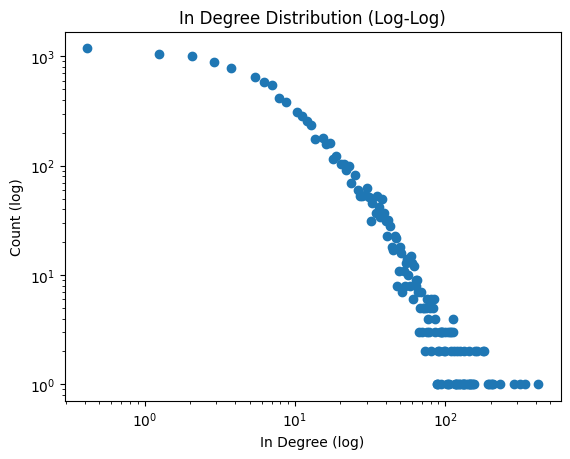

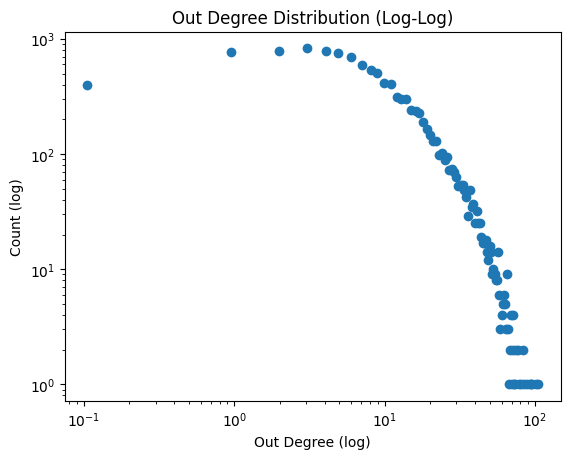

In [7]:
print('Maximum In Degree: ' + str(max(dict(network.in_degree()).values())))
print('Minimum In Degree: ' + str(min(dict(network.in_degree()).values())))

print('Maximum Out Degree: ' + str(max(dict(network.out_degree()).values())))
print('Minimum Out Degree: ' + str(min(dict(network.out_degree()).values())))

counts, bin_edges = np.histogram([deg for node, deg in network.in_degree()], 500)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.plot(bin_centers, counts, 'o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('In Degree (log)')
plt.ylabel('Count (log)')
plt.title('In Degree Distribution (Log-Log)')
plt.show()

counts, bin_edges = np.histogram([deg for node, deg in network.out_degree()], 500)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.plot(bin_centers, counts, 'o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Out Degree (log)')
plt.ylabel('Count (log)')
plt.title('Out Degree Distribution (Log-Log)')
plt.show()

I checked the assortativity of the network - expecting high-degree nodes to connect with other high-degree nodes.

In [22]:
# Degree assortativity
assortativity = nx.degree_assortativity_coefficient(network)
print(f"Degree assortativity: {assortativity:.4f}")

Degree assortativity: 0.0631


Since we settled on making an analysis across time, I defined my eras based on the main human history eras. A person is assigned to an era if their birth year is in the time interval defined for the specific era.

In [11]:
era_order_display = [
    'Before Christ (< 30)',
    'Classical Era (30-476)',
    'Middle Ages (476-1450)',
    'Early Modern (1450-1760)',
    'Industrial Era (1760-1840)',
    'Wartime (1840-1945)',
    'Post-War (1945-2025)'
]

def get_era(birth_year):
    """Determine which era a birth year belongs to"""
    if birth_year is None:
        return 'Unknown'
    
    try:
        year = int(birth_year)
    except (ValueError, TypeError):
        return 'Unknown'
    
    if year < 30:
        return 'Before Christ (< 30)'
    elif 30 <= year < 476:
        return 'Classical Era (30-476)'
    elif 476 <= year < 1450:
        return 'Middle Ages (476-1450)'
    elif 1450 <= year < 1760:
        return 'Early Modern (1450-1760)'
    elif 1760 <= year < 1840:
        return 'Industrial Era (1760-1840)'
    elif 1840 <= year < 1945:
        return 'Wartime (1840-1945)'
    elif 1945 <= year <= 2025:
        return 'Post-War (1945-2025)'
    else:
        return 'Unknown'

My main path of focus was birth cities, seeing if I can find some interesting patterns emerging from them. I wanted to see the total number of cities and what are the ones with the most influential people being born there.

In [4]:
# Group nodes by birth city
from collections import defaultdict

city_groups = defaultdict(list)

for node in network.nodes():
    birth_city = network.nodes[node].get('birthcity', 'Unknown')
    city_groups[birth_city].append(node)

# Print summary
print(f"Total unique birth cities: {len(city_groups)}\n")

# Show top 10 cities by number of people
sorted_cities = sorted(city_groups.items(), key=lambda x: len(x[1]), reverse=True)

print("Top 10 cities by number of people:")
for i, (city, people) in enumerate(sorted_cities[:10], 1):
    print(f"{i:2d}. {city:30s} - {len(people):4d} people")
    # Show first 3 people from this city
    for person in people[:3]:
        print(f"     - {person}")
    if len(people) > 3:
        print(f"     ... and {len(people) - 3} more")
    print()

Total unique birth cities: 5074

Top 10 cities by number of people:
 1. OTHER                          -  505 people
     - 37
     - 197
     - 451
     ... and 502 more

 2. NEW YORK                       -  338 people
     - 8844
     - 8845
     - 8846
     ... and 335 more

 3. PARIS                          -  244 people
     - 1631
     - 1642
     - 1669
     ... and 241 more

 4. LOS ANGELES                    -  190 people
     - 8691
     - 8692
     - 8693
     ... and 187 more

 5. LONDON                         -  177 people
     - 919
     - 944
     - 947
     ... and 174 more

 6. ROME                           -  170 people
     - 3954
     - 3973
     - 3977
     ... and 167 more

 7. CHICAGO                        -  107 people
     - 8729
     - 8730
     - 8732
     ... and 104 more

 8. MOSCOW                         -  104 people
     - 5927
     - 5930
     - 5935
     ... and 101 more

 9. ISTANBUL                       -   76 people
     - 1208
     - 7173
  

I removed the 'Other' option and the cities which only had 1 person being born there.

In [6]:
top_cities = sorted_cities[1:1216]

print(f"Top cities (total: {len(top_cities)})")
for i, (city, people) in enumerate(top_cities[:20], 1):
    print(f"{i:2d}. {city:30s} - {len(people):4d} people")

Top cities (total: 1215)
 1. NEW YORK                       -  338 people
 2. PARIS                          -  244 people
 3. LOS ANGELES                    -  190 people
 4. LONDON                         -  177 people
 5. ROME                           -  170 people
 6. CHICAGO                        -  107 people
 7. MOSCOW                         -  104 people
 8. ISTANBUL                       -   76 people
 9. VIENNA                         -   74 people
10. BOSTON                         -   65 people
11. BERLIN                         -   63 people
12. SAN FRANCISCO-BAY AREA         -   62 people
13. SAINT PETERSBURG               -   52 people
14. FLORENCE                       -   50 people
15. BUENOS AIRES                   -   43 people
16. MADRID                         -   43 people
17. MUNICH                         -   42 people
18. BUDAPEST                       -   38 people
19. STOCKHOLM                      -   38 people
20. COPENHAGEN                     -   37 pe

I grouped the influential people by era and birth city.

In [25]:
city_era_groups = {}

for city, people in top_cities:
    city_era_groups[city] = defaultdict(list)
    
    for person in people:
        birth_year = network.nodes[person].get('birthyear', None)
        era = get_era(birth_year)
        city_era_groups[city][era].append(person)

I continued by looking into how different centrality measures change across eras.

In [20]:
# Calculate multiple centrality measures per era
centrality_evolution = []

for era in era_order_display:
    era_nodes = []
    for city, people in top_cities:
        if city in city_era_groups and era in city_era_groups[city]:
            era_nodes.extend(city_era_groups[city][era])
    
    if len(era_nodes) > 5:
        era_subgraph = network.subgraph(era_nodes)
        
        # Calculate centralities
        degree_cent = nx.degree_centrality(era_subgraph)
        between_cent = nx.betweenness_centrality(era_subgraph)
        close_cent = nx.closeness_centrality(era_subgraph)
        
        # Get top nodes by each measure
        top_degree = max(degree_cent.items(), key=lambda x: x[1])
        top_between = max(between_cent.items(), key=lambda x: x[1])
        top_close = max(close_cent.items(), key=lambda x: x[1])
        
        centrality_evolution.append({
            'era': era,
            'top_degree': network.nodes[top_degree[0]].get('Name'),
            'top_betweenness': network.nodes[top_between[0]].get('Name'),
            'top_closeness': network.nodes[top_close[0]].get('Name'),
            'avg_degree': sum(degree_cent.values())/len(degree_cent)
        })

df_cent = pd.DataFrame(centrality_evolution)
print(df_cent)

                          era           top_degree      top_betweenness  \
0        Before Christ (< 30)                Plato                Plato   
1      Classical Era (30-476)               Trajan        Constantine I   
2      Middle Ages (476-1450)          Charlemagne          Charlemagne   
3    Early Modern (1450-1760)  Louis XIV of France  Louis XIV of France   
4  Industrial Era (1760-1840)       Queen Victoria          Victor Hugo   
5         Wartime (1840-1945)      John F. Kennedy        Ronald Reagan   
6        Post-War (1945-2025)         Barack Obama        David Beckham   

       top_closeness  avg_degree  
0             Cicero    0.058063  
1  Septimius Severus    0.056247  
2        Charlemagne    0.016470  
3           Voltaire    0.019561  
4     Queen Victoria    0.015934  
5    John F. Kennedy    0.004570  
6       Barack Obama    0.005866  


I looked for communities using Louvain partitioning.

In [ ]:
# Louvain community detection
from networkx.algorithms import community

communities = community.louvain_communities(network)

print(f"Found {len(communities)} communities")

# Analyze top 5 communities
for i, comm in enumerate(sorted(communities, key=len, reverse=True)[:5], 1):
    print(f"\nCommunity {i}: {len(comm)} members")
    
    # Check which occupations dominate this community
    occupations = [network.nodes[node].get('occupation', 'Unknown') for node in comm]
    top_occupations = Counter(occupations).most_common(3)
    print(f"  Top occupations: {top_occupations}")
    
    # Check what cities dominate the community
    cities = [network.nodes[node].get('birthcity', 'Unknown') for node in comm]
    top_cities = Counter(cities).most_common(3)
    print(f"  Top cities: {top_cities}")
    
    # Sample members
    sample_names = [network.nodes[node].get('Name') for node in list(comm)[:5]]
    print(f"  Sample: {sample_names}")

Found 255 communities

Community 1: 2004 members
  Top occupations: [('POLITICIAN', 1219), ('MILITARY PERSONNEL', 114), ('WRITER', 98)]
  Top cities: [('LONDON', 30), ('NEW YORK', 27), ('MOSCOW', 26)]
  Sample: ['Dmitry Medvedev', 'Andreas Papandreou', 'Ayman al-Zawahiri', 'Felix Wankel', 'Eva Braun']

Community 2: 1753 members
  Top occupations: [('ACTOR', 1083), ('WRITER', 288), ('FILM DIRECTOR', 167)]
  Top cities: [('NEW YORK', 170), ('LOS ANGELES', 107), ('CHICAGO', 55)]
  Sample: ['Charlotte Rampling', 'Jafar Panahi', 'Elizabeth Taylor', 'James Coburn', 'Sterling Knight']

Community 3: 1260 members
  Top occupations: [('POLITICIAN', 251), ('WRITER', 248), ('PHILOSOPHER', 149)]
  Top cities: [('PARIS', 85), ('LONDON', 37), ('MOSCOW', 28)]
  Sample: ['Timothy McVeigh', 'Howard Gardner', 'Pierre-Simon Laplace', 'Honoré de Balzac', 'Romain Rolland']

Community 4: 1125 members
  Top occupations: [('SOCCER PLAYER', 1026), ('COACH', 73), ('REFEREE', 10)]
  Top cities: [('BUENOS AIRES', 

After the broader analysis based on the concepts seen in the lectures, I did a deeper analysis on my assigned focus path: birth cities of influential people.

In order to have a better overview of the cities, I created a heatmap showing the distribuiton of people by city and era in the cities with the most influential people.

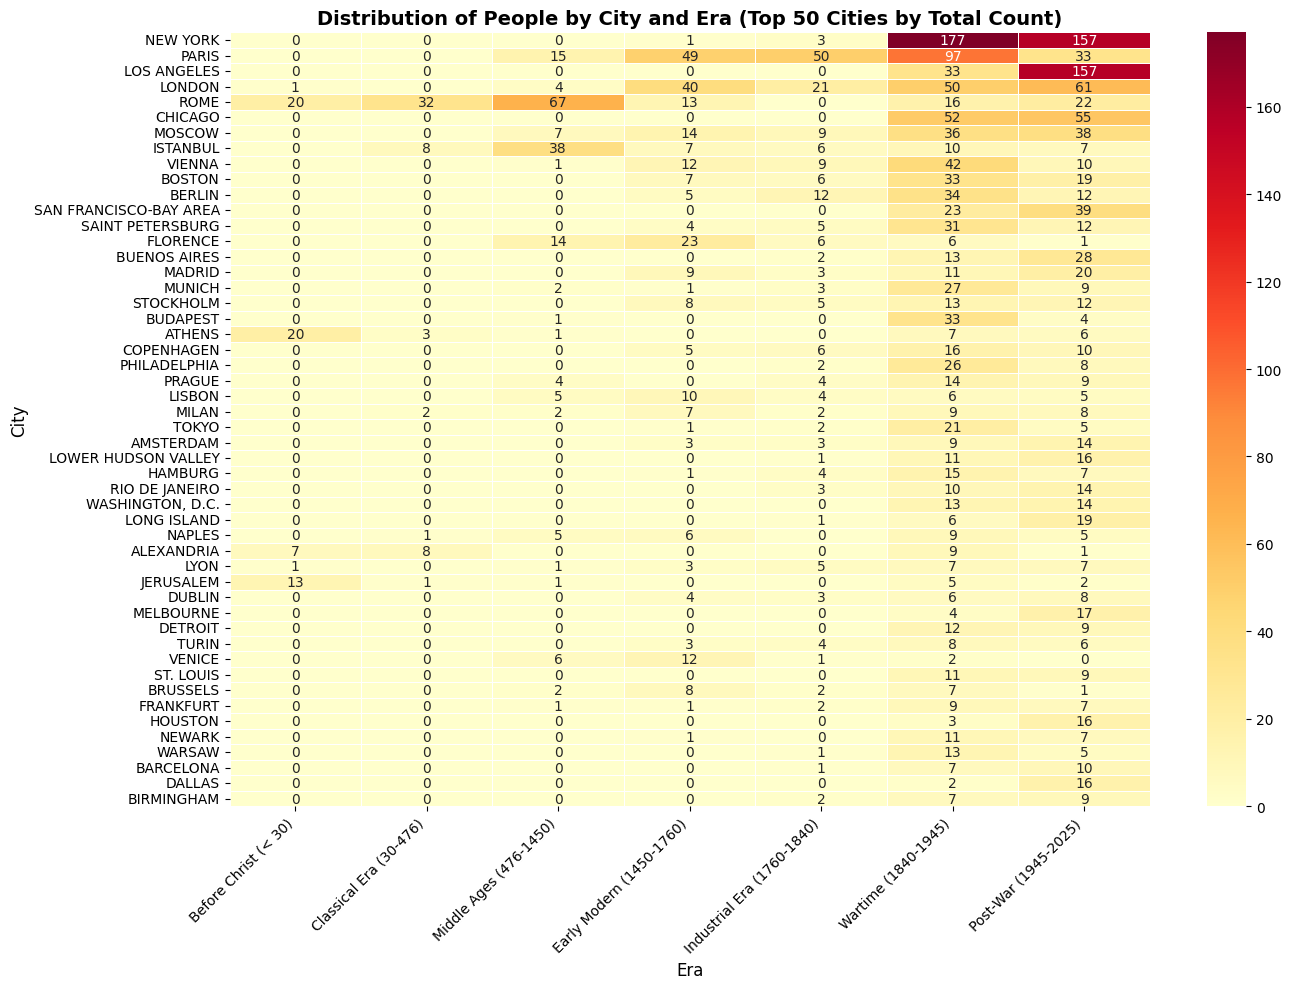

In [27]:
# Heatmap of top cities sorted by total people count
# Sort the pivot table by total count across all eras
# Create summary statistics
summary_data = []

for city, people in top_cities:
    era_dict = city_era_groups[city]
    
    for era, era_people in era_dict.items():
        summary_data.append({
            'city': city,
            'era': era,
            'count': len(era_people)
        })

df_summary = pd.DataFrame(summary_data)

# Pivot to show cities vs eras
df_pivot = df_summary.pivot(index='city', columns='era', values='count').fillna(0).astype(int)

# Reorder columns chronologically
era_order = [
    'Before Christ (< 30)',
    'Classical Era (30-476)',
    'Middle Ages (476-1450)',
    'Early Modern (1450-1760)',
    'Industrial Era (1760-1840)',
    'Wartime (1840-1945)',
    'Post-War (1945-2025)',
    'Unknown'
]

df_pivot = df_pivot[[col for col in era_order if col in df_pivot.columns]]

df_pivot_sorted = df_pivot.copy()
df_pivot_sorted['total'] = df_pivot_sorted.sum(axis=1)
df_pivot_sorted = df_pivot_sorted.sort_values('total', ascending=False)
df_pivot_sorted = df_pivot_sorted.drop('total', axis=1)

# Plot top 50 cities
plt.figure(figsize=(14, 10))
sns.heatmap(df_pivot_sorted.head(50), annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Distribution of People by City and Era (Top 50 Cities by Total Count)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Era', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

I continued visualising cities with most people by eras.

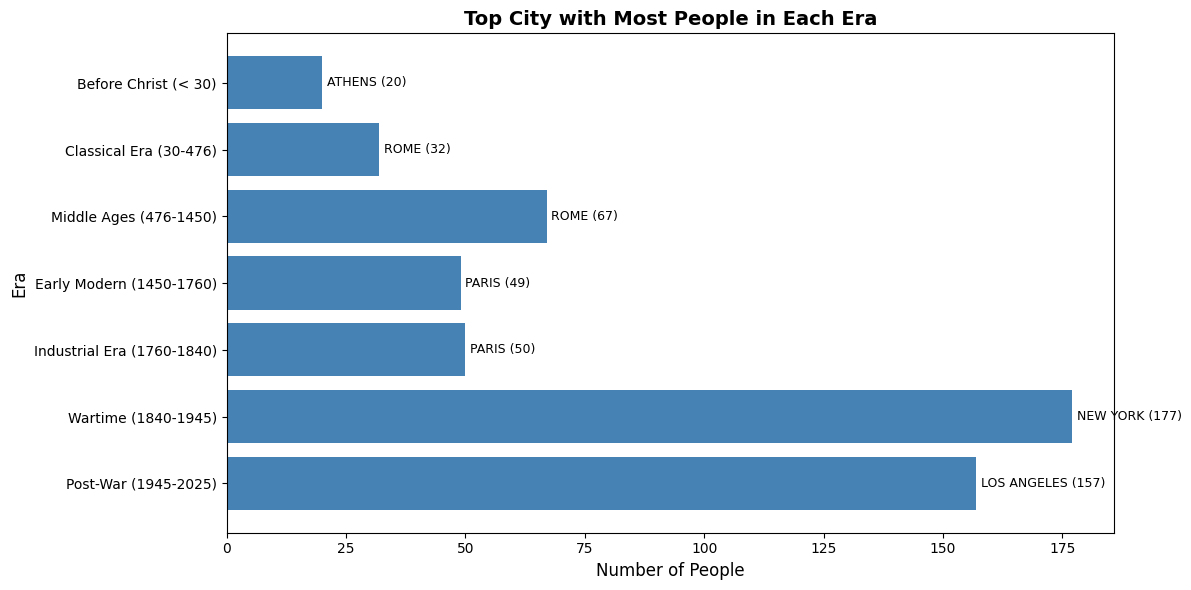

In [28]:
# Create visualization of top city per era
top_cities_per_era = []

for era in era_order:
    if era in df_pivot.columns and df_pivot[era].max() > 0:
        top_city = df_pivot[era].idxmax()
        top_count = df_pivot[era].max()
        top_cities_per_era.append({
            'era': era,
            'city': top_city,
            'count': top_count
        })

df_top = pd.DataFrame(top_cities_per_era)

# Plot
plt.figure(figsize=(12, 6))
bars = plt.barh(df_top['era'], df_top['count'], color='steelblue')

# Add city names on the bars
for i, (era, city, count) in enumerate(zip(df_top['era'], df_top['city'], df_top['count'])):
    plt.text(count + 1, i, f'{city} ({count})', va='center', fontsize=9)

plt.xlabel('Number of People', fontsize=12)
plt.ylabel('Era', fontsize=12)
plt.title('Top City with Most People in Each Era', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

I checked the top 5 cities with most influential people in each era.

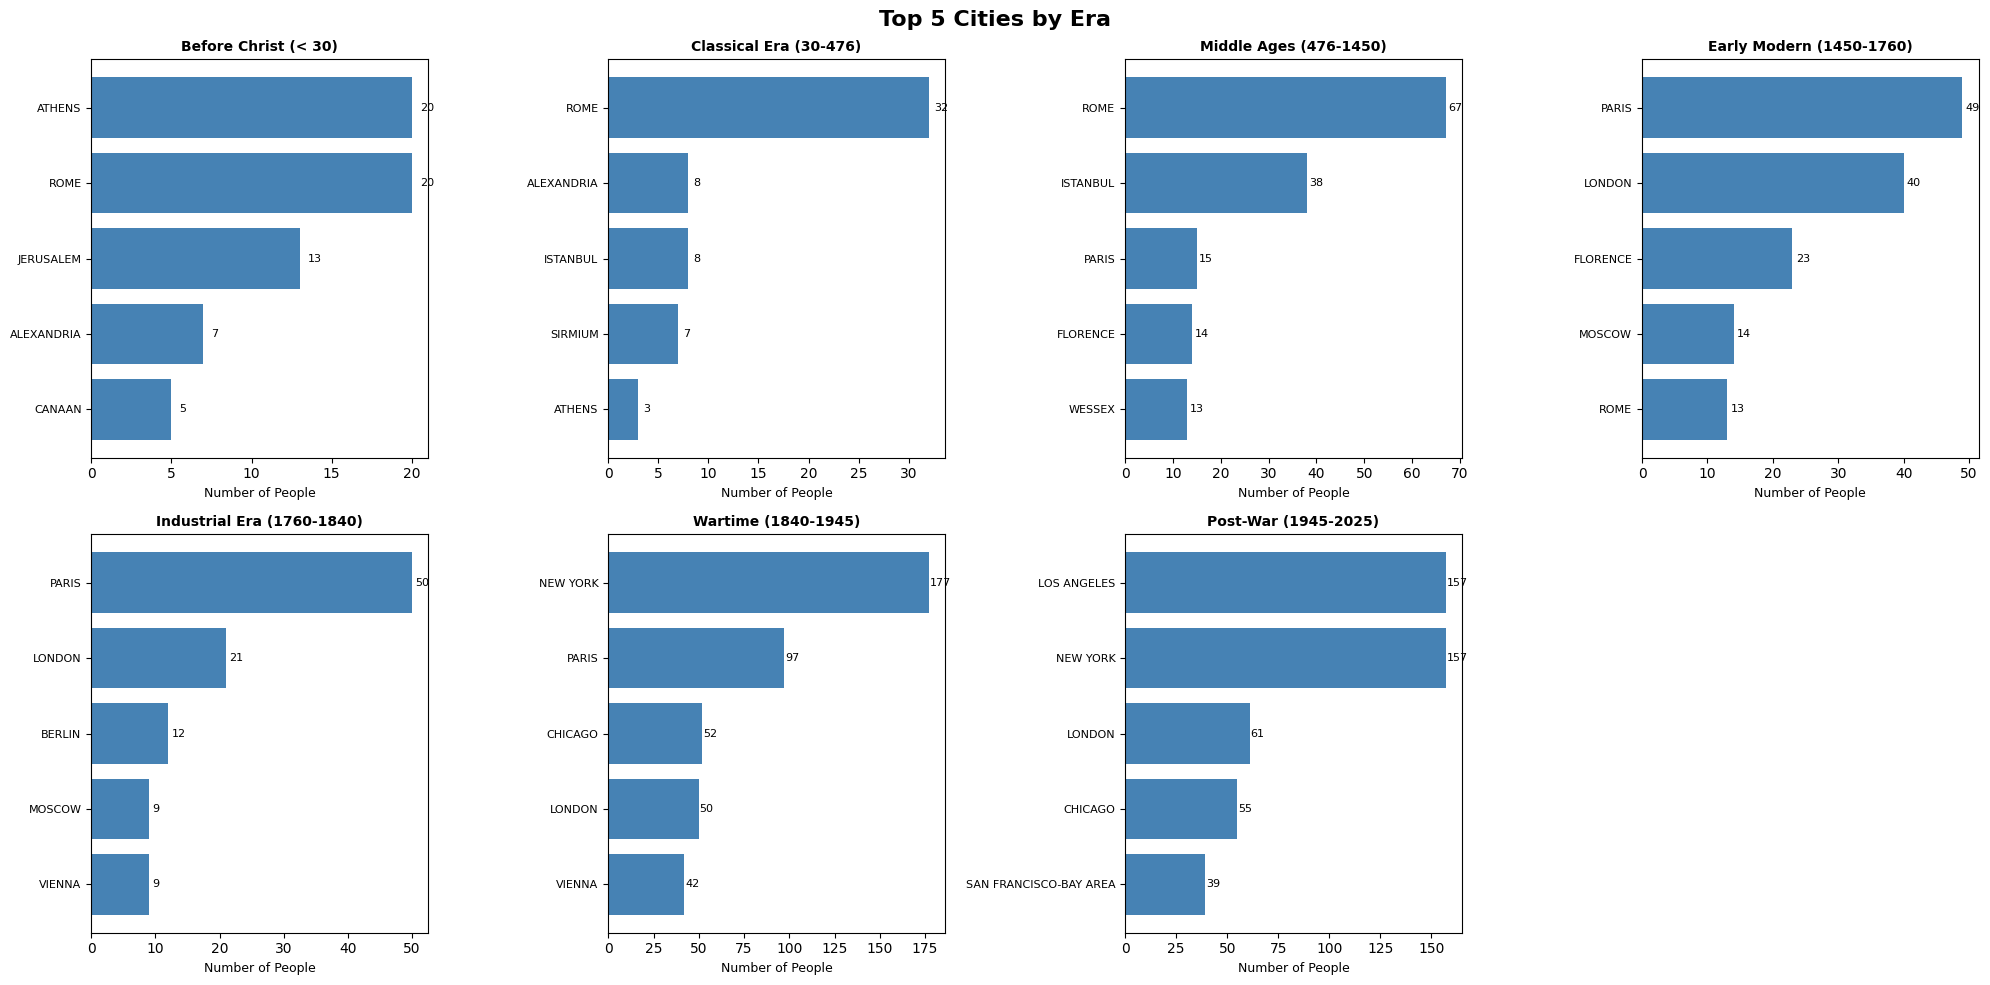

In [29]:
# Create grouped bar chart for top 5 cities per era
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, era in enumerate([e for e in era_order if e in df_pivot.columns and df_pivot[e].max() > 0]):
    # Get top 5 cities for this era
    top_5 = df_pivot[era].nlargest(5)
    
    ax = axes[idx]
    ax.barh(range(len(top_5)), top_5.values, color='steelblue')
    ax.set_yticks(range(len(top_5)))
    ax.set_yticklabels(top_5.index, fontsize=8)
    ax.set_xlabel('Number of People', fontsize=9)
    ax.set_title(f'{era}', fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    
    # Add count labels on bars
    for i, v in enumerate(top_5.values):
        ax.text(v + 0.5, i, str(int(v)), va='center', fontsize=8)

# Hide unused subplots
for idx in range(len([e for e in era_order if e in df_pivot.columns and df_pivot[e].max() > 0]), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Top 5 Cities by Era', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

One idea that we wanted to explore was to check whether we could find a correlation between the 'sentiment' of a city and the number of influential people being born there. We decided to define the 'sentiment' of the city as the average sentiment of the Wiki pages of the people born in a city. As the Wikipedia pages have a neutral tone, there was no clear relationship between the cities and the total number of famous people coming from them. Below is the sentiment analysis with the results, however this is not included in the paper.

In [ ]:
# Set the sentiment as a node attribute
nx.set_node_attributes(network, "", "sentiment")

In [ ]:
def parse_labmit_file(file_content):
    word_scores = {}
    # Decode bytes to string if needed
    if isinstance(file_content, bytes):
        file_content = file_content.decode('utf-8')
    
    lines = file_content.strip().split('\n')
    
    # Skip header lines (first 3 lines)
    for line in lines[3:]:
        parts = line.split('\t')
        if len(parts) >= 3:
            word = parts[0].strip()
            try:
                happiness_avg = float(parts[2].strip())
                word_scores[word] = happiness_avg
            except ValueError:
                continue
    
    return word_scores


# Load the labMIT file from GitHub
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/labMT_wordlist.txt"
    
try:
    with urllib.request.urlopen(url) as response:
        labmt_content = response.read()
    word_scores = parse_labmit_file(labmt_content)
    print(f"Loaded {len(word_scores)} words with happiness scores")
except Exception as e:
    print(f"Error loading file: {str(e)}")
    word_scores = {}

Loaded 10222 words with happiness scores


In [ ]:
# Calculate sentiment as the average of the word scores
def calculate_sentiment(tokens):
    sum = 0
    len = 0
    for token in tokens:
        if token in word_scores:
            sum = sum + word_scores[token]
            len+=1
    return sum / len

In [ ]:
def clean_tokenize_lemmatize_nltk(text):
    # If input is JSON string, extract the wikitext content
    if isinstance(text, str) and text.strip().startswith('{'):
        try:
            data = json.loads(text)
            # Navigate through the JSON structure to get wikitext
            pages = data.get('query', {}).get('pages', {})
            # Get the first (and usually only) page
            page_content = next(iter(pages.values()))
            text = page_content.get('revisions', [{}])[0].get('slots', {}).get('main', {}).get('*', '')
        except (json.JSONDecodeError, KeyError, StopIteration):
            pass  # If parsing fails, treat as plain text
    
    # Remove MediaWiki markup
    # Remove {{templates}}
    text = re.sub(r'\{\{[^}]*\}\}', '', text)
    # Remove [[links]] but keep the text
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]+)\]\]', r'\1', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove reference tags like <ref>...</ref>
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove file/image references
    text = re.sub(r'\[\[File:.*?\]\]|\[\[Image:.*?\]\]', '', text, flags=re.IGNORECASE)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation but keep spaces
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and very short tokens
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Remove any remaining non-alphabetic tokens
    tokens = [token for token in tokens if token.isalpha()]

    # Remove all occurrences of 'nbsp' and 'also' - noticed after testing
    tokens = [token for token in tokens if token not in {'nbsp', 'also', 'align', 'center', 'nugent', 'ncategory', 'text', 'nin', 'parser', 'output', 'hlist', 'html', 'navbox', 'font', 'sidebar', 'infobox'}]
    
    return tokens

I had to remove some nodes because the sentiment analysis was taking a lot of time for all the nodes. I kept the nodes which had the birth city as one of the top 100 cities with most influential people.

In [41]:
# Create a new network with only nodes from top 100 cities
# Get nodes from top 100 cities
nodes_to_keep = set()
for city, people in top_cities[:100]:
    nodes_to_keep.update(people)

# Create subgraph with only these nodes
network_top100 = network.subgraph(nodes_to_keep).copy()

print(f"\nFiltered network created!")
print(f"  Top 100 cities network: {network_top100.number_of_nodes()} nodes, {network_top100.number_of_edges()} edges")

# Update top_cities to only include the 100 cities
top_cities_100 = top_cities[:100]

# Rebuild city_era_groups for top 100 cities only
city_era_groups_100 = {}

for city, people in top_cities_100:
    city_era_groups_100[city] = defaultdict(list)
    
    for person in people:
        birth_year = network_top100.nodes[person].get('birthyear', None)
        era = get_era(birth_year)
        city_era_groups_100[city][era].append(person)

full_network = network
full_top_cities = top_cities
full_city_era_groups = city_era_groups
# Use these for sentiment calculation
network = network_top100
top_cities = top_cities_100
city_era_groups = city_era_groups_100


Filtered network created!
  Top 100 cities network: 3422 nodes, 17581 edges


In [ ]:
# Calculate sentiment for each city-era pair
from collections import defaultdict

# First, calculate sentiment for each node using the Link attribute
print("Calculating sentiment for each person...")

node_sentiments = {}
errors = []

for i, node in enumerate(network.nodes(), 1):
    if i % 100 == 0:
        print(f"  Processed {i}/{network.number_of_nodes()} nodes...")
    try:
        # Get the Wikipedia link from node attributes
        wiki_link = network.nodes[node].get('Link', '')
        
        if wiki_link:
            # Extract page title from URL
            page_title = wiki_link.split('/wiki/')[-1]
            
            # Use Wikipedia API to get clean plain text content
            api_url = f"https://en.wikipedia.org/w/api.php?action=query&format=json&titles={page_title}&prop=extracts&explaintext=true"
            
            req = urllib.request.Request(api_url, headers={'User-Agent': "Magic Browser"}) 
            con = urllib.request.urlopen(req)
            response = con.read().decode('utf-8')
            data = json.loads(response)
            
            # Extract the text content
            pages = data['query']['pages']
            for page_id in pages:
                if 'extract' in pages[page_id]:
                    content = pages[page_id]['extract']
                    break
            
            # Clean and tokenize
            tokens = clean_tokenize_lemmatize_nltk(content)
            
            # Calculate sentiment
            if len(tokens) > 0:
                sentiment = calculate_sentiment(tokens)
                node_sentiments[node] = sentiment
                network.nodes[node]['sentiment'] = sentiment
            else:
                node_sentiments[node] = 0
                network.nodes[node]['sentiment'] = 0
        else:
            node_sentiments[node] = 0
            network.nodes[node]['sentiment'] = 0
            
    except Exception as e:
        errors.append((node, str(e)))
        node_sentiments[node] = 0
        network.nodes[node]['sentiment'] = 0

# Now calculate average sentiment for each city-era pair
city_era_sentiments = {}

for city, people in top_cities:
    city_era_sentiments[city] = {}
    
    era_dict = city_era_groups[city]
    
    for era, era_people in era_dict.items():
        # Get sentiments for all people in this city-era pair
        sentiments = [node_sentiments.get(person, 0) for person in era_people]
        valid_sentiments = [s for s in sentiments if s != 0]
        
        if len(valid_sentiments) > 0:
            avg_sentiment = sum(valid_sentiments) / len(valid_sentiments)
            city_era_sentiments[city][era] = avg_sentiment
        else:
            city_era_sentiments[city][era] = 0

In [44]:
print("\nAverage sentiment by city and era:\n")
for i, (city, people) in enumerate(top_cities[:10], 1):
    print(f"{i}. {city}")
    
    for era in era_order:
        if era in city_era_sentiments[city] and city_era_sentiments[city][era] > 0:
            sentiment = city_era_sentiments[city][era]
            count = len(city_era_groups[city][era])
            print(f"  {era:30s}: {sentiment:.3f} ({count} people)")
    print()


Average sentiment by city and era:

1. NEW YORK
  Early Modern (1450-1760)      : 5.597 (1 people)
  Industrial Era (1760-1840)    : 5.702 (3 people)
  Wartime (1840-1945)           : 5.770 (177 people)
  Post-War (1945-2025)          : 5.812 (157 people)

2. PARIS
  Middle Ages (476-1450)        : 5.525 (15 people)
  Early Modern (1450-1760)      : 5.669 (49 people)
  Industrial Era (1760-1840)    : 5.740 (50 people)
  Wartime (1840-1945)           : 5.761 (97 people)
  Post-War (1945-2025)          : 5.815 (33 people)

3. LOS ANGELES
  Wartime (1840-1945)           : 5.744 (33 people)
  Post-War (1945-2025)          : 5.820 (157 people)

4. LONDON
  Before Christ (< 30)          : 5.630 (1 people)
  Middle Ages (476-1450)        : 5.591 (4 people)
  Early Modern (1450-1760)      : 5.666 (40 people)
  Industrial Era (1760-1840)    : 5.665 (21 people)
  Wartime (1840-1945)           : 5.743 (50 people)
  Post-War (1945-2025)          : 5.836 (61 people)

5. ROME
  Before Christ (< 30)

In the list below of the 'happiest' cities I believe there are some interesting findings. Even though the Wikipedia tone is mostly neutral, we can still see Honolulu, a city in Hawaii which is characterized as a vacation, sunny place has a high sentiment while Jerusalem or Mecca, highly religious places, are found as some of the least happy.

In [45]:
# Calculate average sentiment for each city
city_avg_sentiments = {}

for city, people in top_cities:
    # Get all sentiment values for people in this city
    city_sentiments = [node_sentiments.get(person, 0) for person in people]
    valid_sentiments = [s for s in city_sentiments if s != 0]
    
    if len(valid_sentiments) > 0:
        avg_sentiment = sum(valid_sentiments) / len(valid_sentiments)
        city_avg_sentiments[city] = {
            'avg_sentiment': avg_sentiment,
            'total_people': len(people),
            'people_with_sentiment': len(valid_sentiments)
        }

# Sort cities by average sentiment
sorted_cities_by_sentiment = sorted(city_avg_sentiments.items(), 
                                   key=lambda x: x[1]['avg_sentiment'], 
                                   reverse=True)

# Display top 100 cities by sentiment
print("Top 100 Cities by Average Sentiment")
print("=" * 80)
print(f"{'Rank':<6} {'City':<35} {'Avg Sentiment':<15} {'People':<10}")
print("-" * 80)

for rank, (city, data) in enumerate(sorted_cities_by_sentiment[:100], 1):
    print(f"{rank:<6} {city:<35} {data['avg_sentiment']:<15.4f} "
          f"{data['people_with_sentiment']}")

Top 100 Cities by Average Sentiment
Rank   City                                Avg Sentiment   People    
--------------------------------------------------------------------------------
1      TORONTO                             5.8565          12
2      HONOLULU                            5.8408          9
3      HOUSTON                             5.8316          14
4      MELBOURNE                           5.8291          18
5      MEXICO CITY                         5.8284          8
6      HAMMERSMITH                         5.8208          10
7      MUMBAI                              5.8145          14
8      SYDNEY                              5.8130          16
9      DALLAS                              5.8114          17
10     SPRINGFIELD                         5.8070          10
11     LOS ANGELES                         5.8065          181
12     SAN DIEGO                           5.8056          12
13     BARCELONA                           5.8035          7
14     PI

I compared the top 30 cities with most influential people born there with the bottom 30 in terms of happiness.

In [46]:
# Create a ranking showing cities by number of people with their sentiment
city_ranking_with_sentiment = []

for city, people in top_cities:
    # Get sentiment data if available
    if city in city_avg_sentiments:
        city_ranking_with_sentiment.append({
            'City': city,
            'Total People': len(people),
            'People with Sentiment': city_avg_sentiments[city]['people_with_sentiment'],
            'Average Sentiment': city_avg_sentiments[city]['avg_sentiment']
        })
    else:
        city_ranking_with_sentiment.append({
            'City': city,
            'Total People': len(people),
            'People with Sentiment': 0,
            'Average Sentiment': 0.0
        })

# Create DataFrame (already sorted by number of people)
df_city_ranking = pd.DataFrame(city_ranking_with_sentiment)

# Display top 30 cities
print("Cities Ranked by Number of Influential People (with Sentiment)")
print("=" * 100)
print(f"{'Rank':<6} {'City':<35}  {'Avg Sentiment':<15}")
print("-" * 100)

for rank, row in enumerate(df_city_ranking.head(30).itertuples(), 1):
    print(f"{rank:<6} {row.City:<35} {row._4:<15.4f}")

Cities Ranked by Number of Influential People (with Sentiment)
Rank   City                                 Avg Sentiment  
----------------------------------------------------------------------------------------------------
1      NEW YORK                            5.7882         
2      PARIS                               5.7369         
3      LOS ANGELES                         5.8065         
4      LONDON                              5.7447         
5      ROME                                5.6250         
6      CHICAGO                             5.7697         
7      MOSCOW                              5.6958         
8      ISTANBUL                            5.5521         
9      VIENNA                              5.7025         
10     BOSTON                              5.7370         
11     BERLIN                              5.6560         
12     SAN FRANCISCO-BAY AREA              5.7649         
13     SAINT PETERSBURG                    5.7132         
14     FL

It turns out that actually the sentiment is higher for the bottom 30 cities by total number of famous people. This can be explained as more people leading to more chances of less 'happy' celebrities.

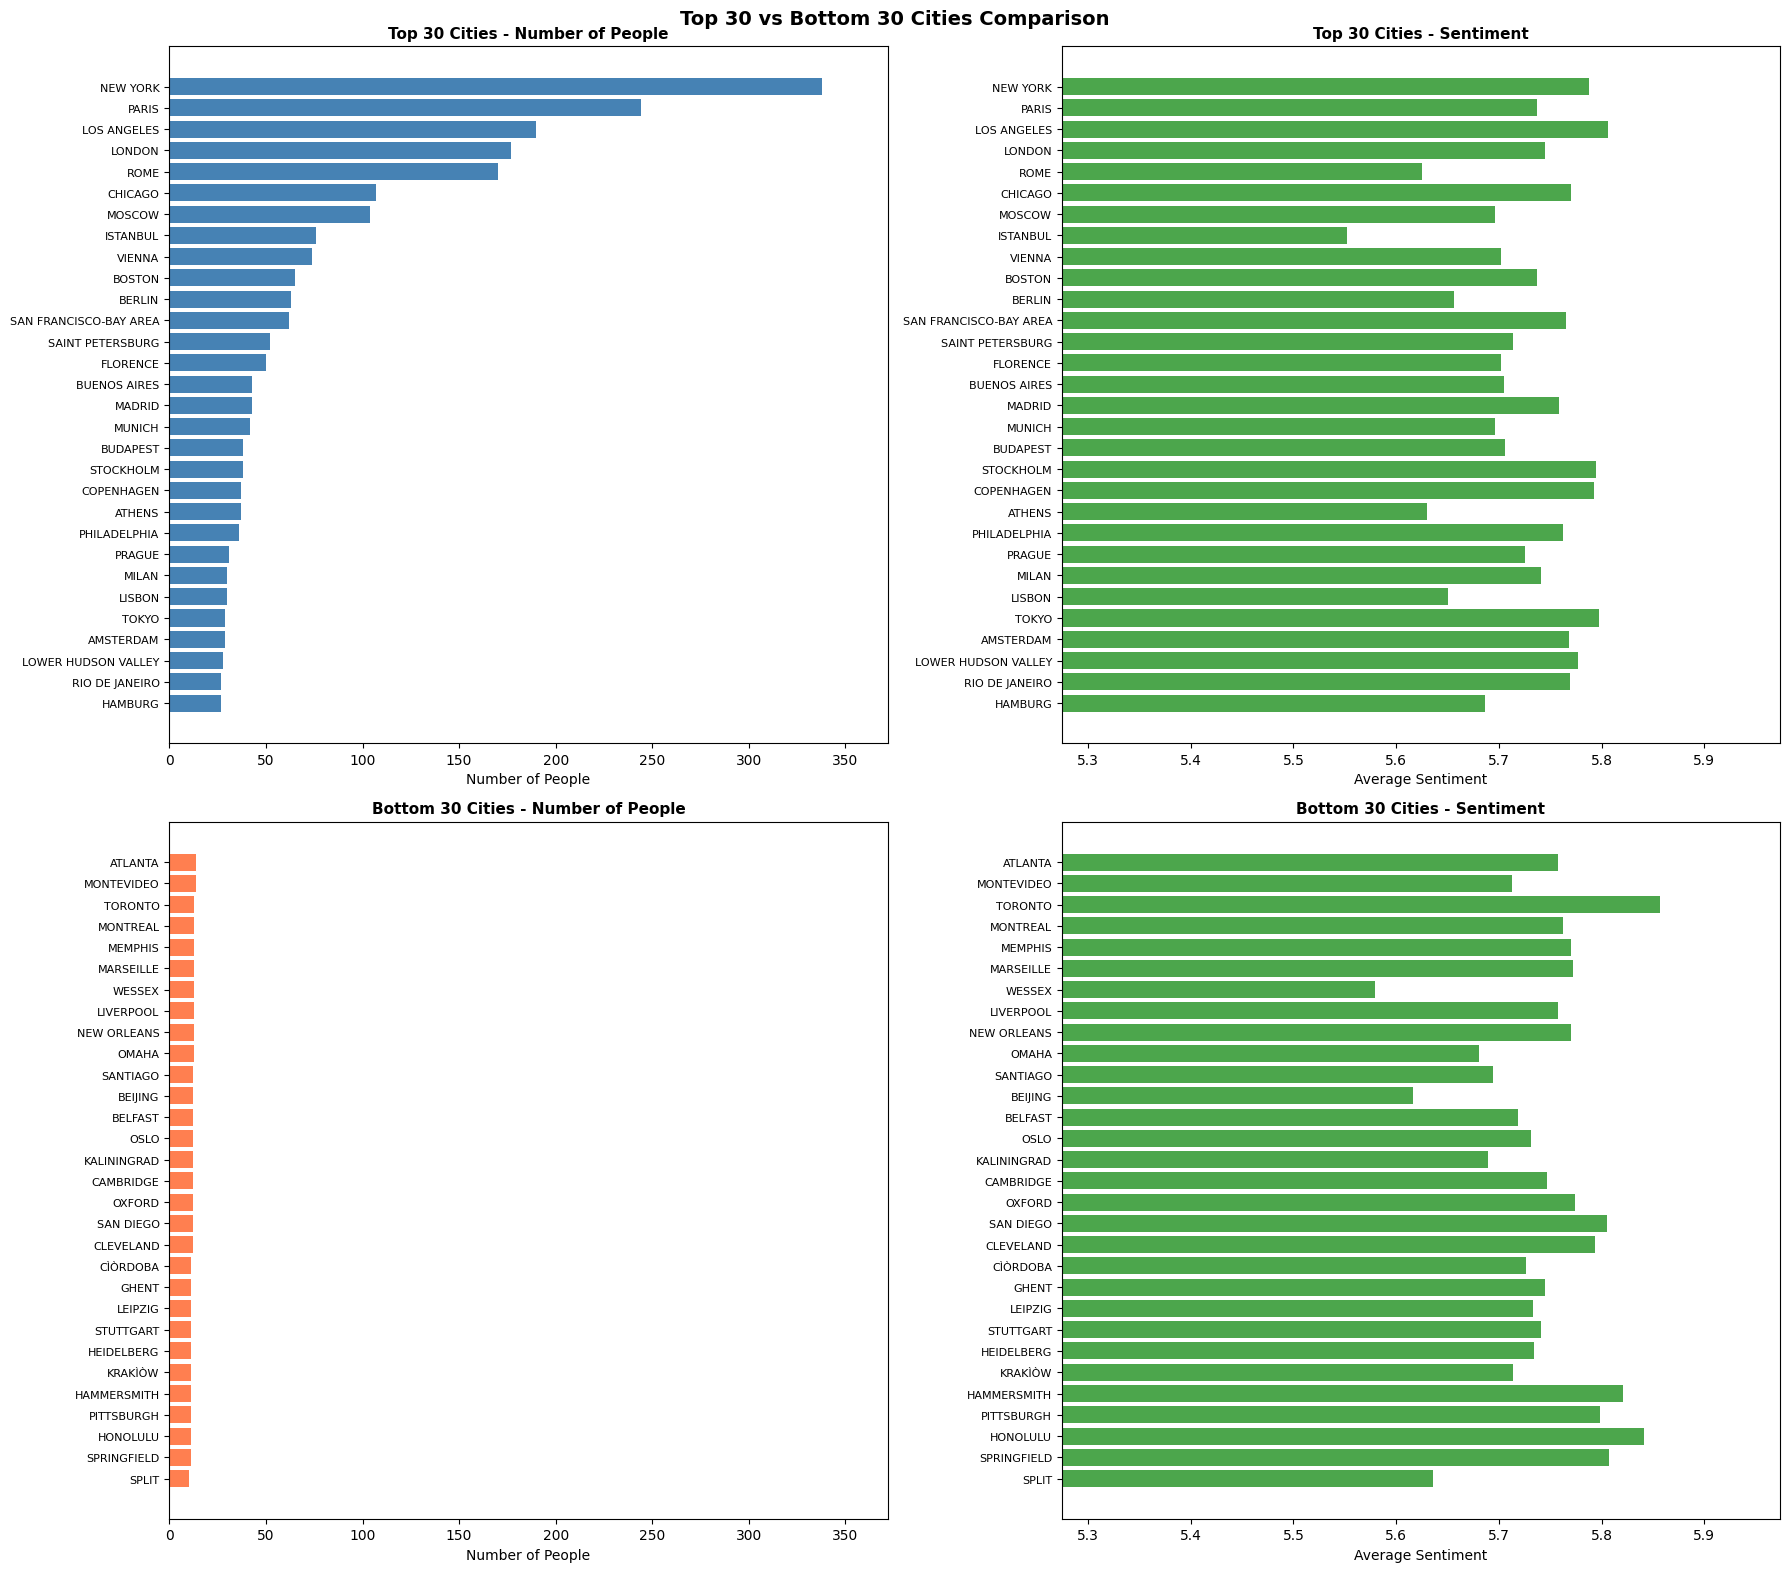


Comparison Statistics:
Top 30 cities:
  Avg sentiment: 5.7251
  Avg people: 77.23

Bottom 30 cities:
  Avg sentiment: 5.7428
  Avg people: 12.00


In [47]:
# Compare top 30 vs bottom 30
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

top_30 = df_city_ranking.head(30)
bottom_30 = df_city_ranking.tail(30)

# Find max values for consistent scaling
max_people = max(top_30['Total People'].max(), bottom_30['Total People'].max())
max_sentiment = max(top_30['Average Sentiment'].max(), bottom_30['Average Sentiment'].max())
min_sentiment = min(top_30['Average Sentiment'].min(), bottom_30['Average Sentiment'].min())

# Top 30 - Number of people
axes[0, 0].barh(range(len(top_30)), top_30['Total People'], color='steelblue')
axes[0, 0].set_yticks(range(len(top_30)))
axes[0, 0].set_yticklabels(top_30['City'], fontsize=8)
axes[0, 0].set_xlabel('Number of People', fontsize=10)
axes[0, 0].set_title('Top 30 Cities - Number of People', fontsize=11, fontweight='bold')
axes[0, 0].set_xlim(0, max_people * 1.1)  # Set consistent x-axis limit
axes[0, 0].invert_yaxis()

# Top 30 - Sentiment
colors_top = ['green' if s > 5.0 else 'orange' if s > 4.5 else 'red' 
              for s in top_30['Average Sentiment']]
axes[0, 1].barh(range(len(top_30)), top_30['Average Sentiment'], color=colors_top, alpha=0.7)
axes[0, 1].set_yticks(range(len(top_30)))
axes[0, 1].set_yticklabels(top_30['City'], fontsize=8)
axes[0, 1].set_xlabel('Average Sentiment', fontsize=10)
axes[0, 1].set_title('Top 30 Cities - Sentiment', fontsize=11, fontweight='bold')
axes[0, 1].set_xlim(min_sentiment * 0.95, max_sentiment * 1.02)  # Set consistent x-axis limit
axes[0, 1].axvline(x=5.0, color='black', linestyle='--', alpha=0.3)
axes[0, 1].invert_yaxis()

# Bottom 30 - Number of people
axes[1, 0].barh(range(len(bottom_30)), bottom_30['Total People'], color='coral')
axes[1, 0].set_yticks(range(len(bottom_30)))
axes[1, 0].set_yticklabels(bottom_30['City'], fontsize=8)
axes[1, 0].set_xlabel('Number of People', fontsize=10)
axes[1, 0].set_title('Bottom 30 Cities - Number of People', fontsize=11, fontweight='bold')
axes[1, 0].set_xlim(0, max_people * 1.1)  # Set consistent x-axis limit
axes[1, 0].invert_yaxis()

# Bottom 30 - Sentiment
colors_bottom = ['green' if s > 5.0 else 'orange' if s > 4.5 else 'red' 
                 for s in bottom_30['Average Sentiment']]
axes[1, 1].barh(range(len(bottom_30)), bottom_30['Average Sentiment'], color=colors_bottom, alpha=0.7)
axes[1, 1].set_yticks(range(len(bottom_30)))
axes[1, 1].set_yticklabels(bottom_30['City'], fontsize=8)
axes[1, 1].set_xlabel('Average Sentiment', fontsize=10)
axes[1, 1].set_title('Bottom 30 Cities - Sentiment', fontsize=11, fontweight='bold')
axes[1, 1].set_xlim(min_sentiment * 0.95, max_sentiment * 1.02)  # Set consistent x-axis limit
axes[1, 1].axvline(x=5.0, color='black', linestyle='--', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.suptitle('Top 30 vs Bottom 30 Cities Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print statistics
print("\nComparison Statistics:")
print(f"Top 30 cities:")
print(f"  Avg sentiment: {top_30['Average Sentiment'].mean():.4f}")
print(f"  Avg people: {top_30['Total People'].mean():.2f}")
print(f"\nBottom 30 cities:")
print(f"  Avg sentiment: {bottom_30['Average Sentiment'].mean():.4f}")
print(f"  Avg people: {bottom_30['Total People'].mean():.2f}")

I visualised some of the people and their occupations from the 5 happiest cities. What is maybe interesting is that most people are actors and if they are politicians, they are mostly positive figures such as Barack Obama.

In [54]:
# Get top 5 cities by sentiment
top_5_happiest = sorted_cities_by_sentiment[:5]

print("People from the Top 5 Happiest Cities")
print("=" * 80)

for rank, (city, data) in enumerate(top_5_happiest, 1):
    print(f"\n{rank}. {city}")
    print(f"   Average Sentiment: {data['avg_sentiment']:.4f}")
    print(f"   Total People: {data['total_people']}")
    print("-" * 80)
    
    # Get the list of people from this city
    city_people = None
    for c, people in top_cities:
        if c == city:
            city_people = people
            break
    
    if city_people:
        # Show all people with their sentiment scores
        people_with_scores = []
        for person in city_people:
            sentiment = node_sentiments.get(person, 0)
            if sentiment > 0:
                name = network.nodes[person].get('Name', person)
                occupation = network.nodes[person].get('occupation', 'N/A')
                people_with_scores.append((name, sentiment, person, occupation))
        
        # Sort by sentiment
        people_with_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Display all people
        for i, (name, sentiment, node_id, occupation) in enumerate(people_with_scores, 1):
            birth_year = network.nodes[node_id].get('birthyear', 'N/A')
            print(f"   {i:3d}. {name:<30s} | {occupation:<25s} | Sentiment: {sentiment:.4f} (born {birth_year})")

People from the Top 5 Happiest Cities

1. TORONTO
   Average Sentiment: 5.8565
   Total People: 13
--------------------------------------------------------------------------------
     1. Howard Shore                   | COMPOSER                  | Sentiment: 6.1024 (born 1946.0)
     2. Frank Gehry                    | ARCHITECT                 | Sentiment: 5.9764 (born 1929.0)
     3. Christopher Plummer            | ACTOR                     | Sentiment: 5.9750 (born 1929.0)
     4. Tara Strong                    | ACTOR                     | Sentiment: 5.9386 (born 1973.0)
     5. Chris Diamantopoulos           | ACTOR                     | Sentiment: 5.9013 (born 1975.0)
     6. Neil Young                     | MUSICIAN                  | Sentiment: 5.8847 (born 1945.0)
     7. Mary Pickford                  | ACTOR                     | Sentiment: 5.8775 (born 1892.0)
     8. Cory Doctorow                  | WRITER                    | Sentiment: 5.8537 (born 1971.0)
     9. Glen

I created a wordcloud for each era for each of the 3 cities with the most influential people. The wordcloud is based on the Wikipedia content of the influential people from that city. Some findings I believe slightly interesting are that Los Angeles is dominated by 'film', Wartime and Industrial eras are dominated by 'work'.

Top 3 cities for wordcloud analysis:
1. NEW YORK: 338 people
2. PARIS: 244 people
3. LOS ANGELES: 190 people

Processing City 1: NEW YORK

  Era: Post-War (1945-2025) (157 people)
  Fetched content for 156/157 people (1 errors)

  Era: Wartime (1840-1945) (177 people)
  Fetched content for 176/177 people (1 errors)

  Era: Industrial Era (1760-1840) (3 people)
  Fetched content for 3/3 people (0 errors)

  Era: Early Modern (1450-1760) (1 people)
  Fetched content for 1/1 people (0 errors)


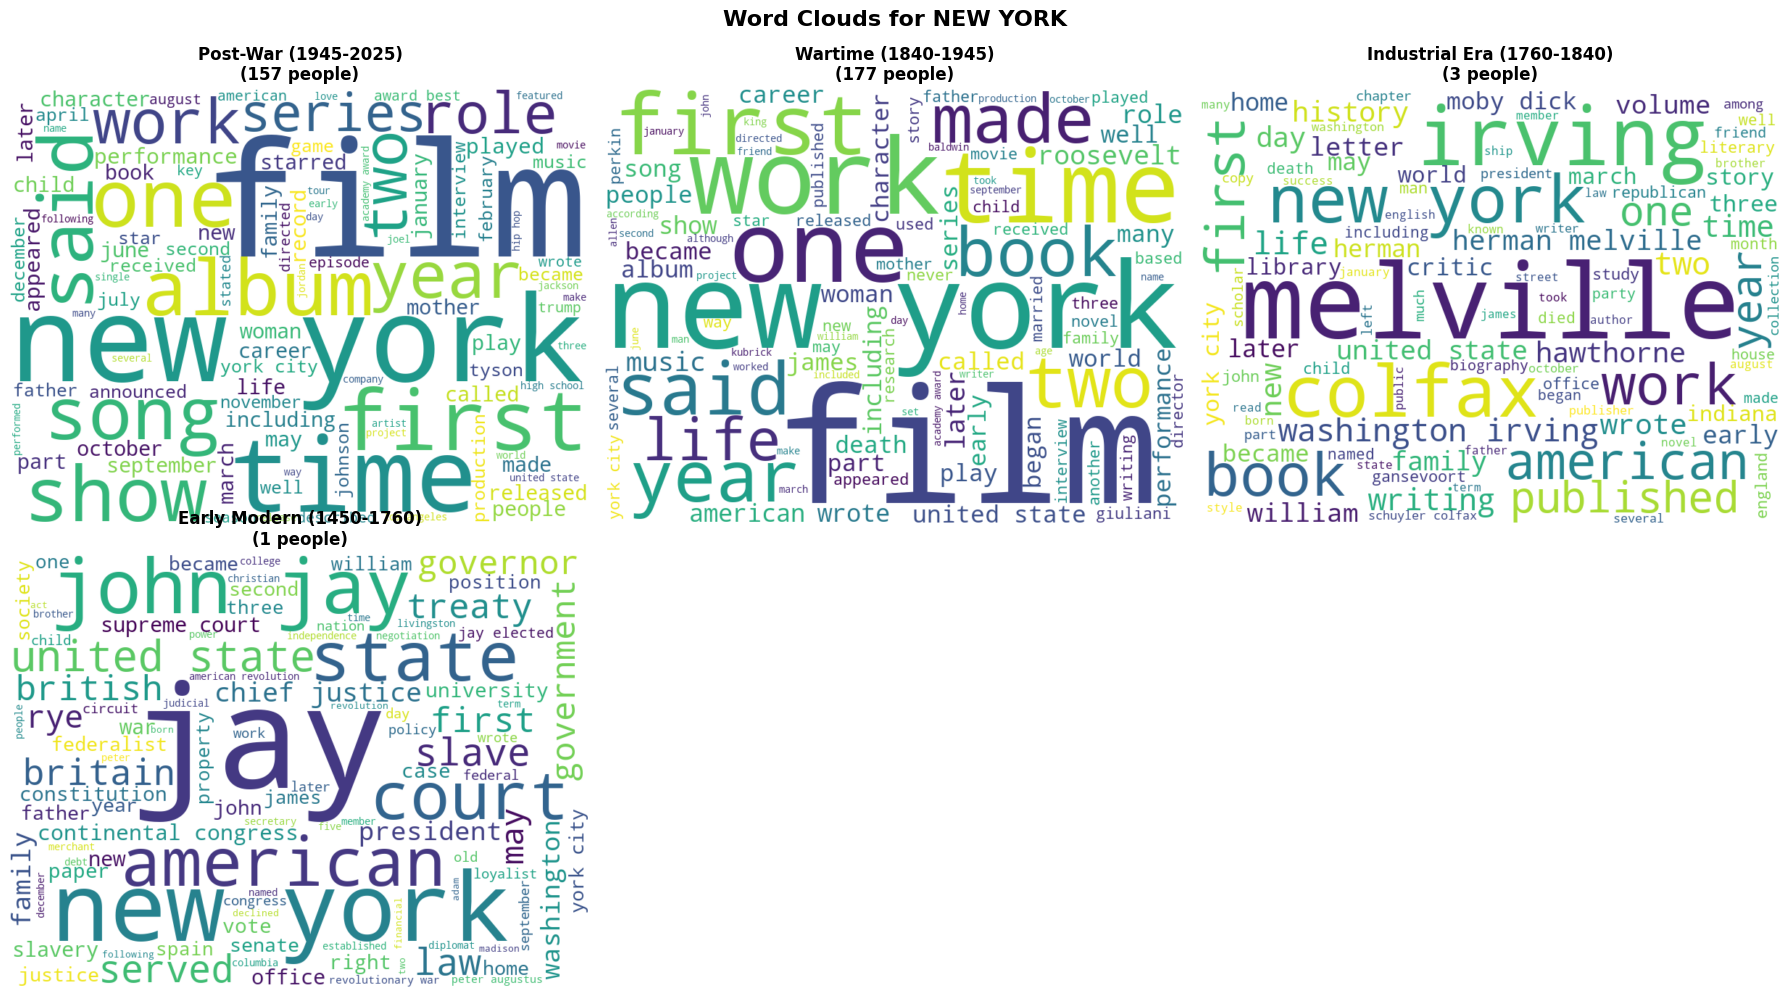


Processing City 2: PARIS

  Era: Wartime (1840-1945) (97 people)
  Fetched content for 72/97 people (25 errors)

  Era: Middle Ages (476-1450) (15 people)
  Fetched content for 13/15 people (2 errors)

  Era: Early Modern (1450-1760) (49 people)
  Fetched content for 34/49 people (15 errors)

  Era: Industrial Era (1760-1840) (50 people)
  Fetched content for 37/50 people (13 errors)

  Era: Post-War (1945-2025) (33 people)
  Fetched content for 28/33 people (5 errors)


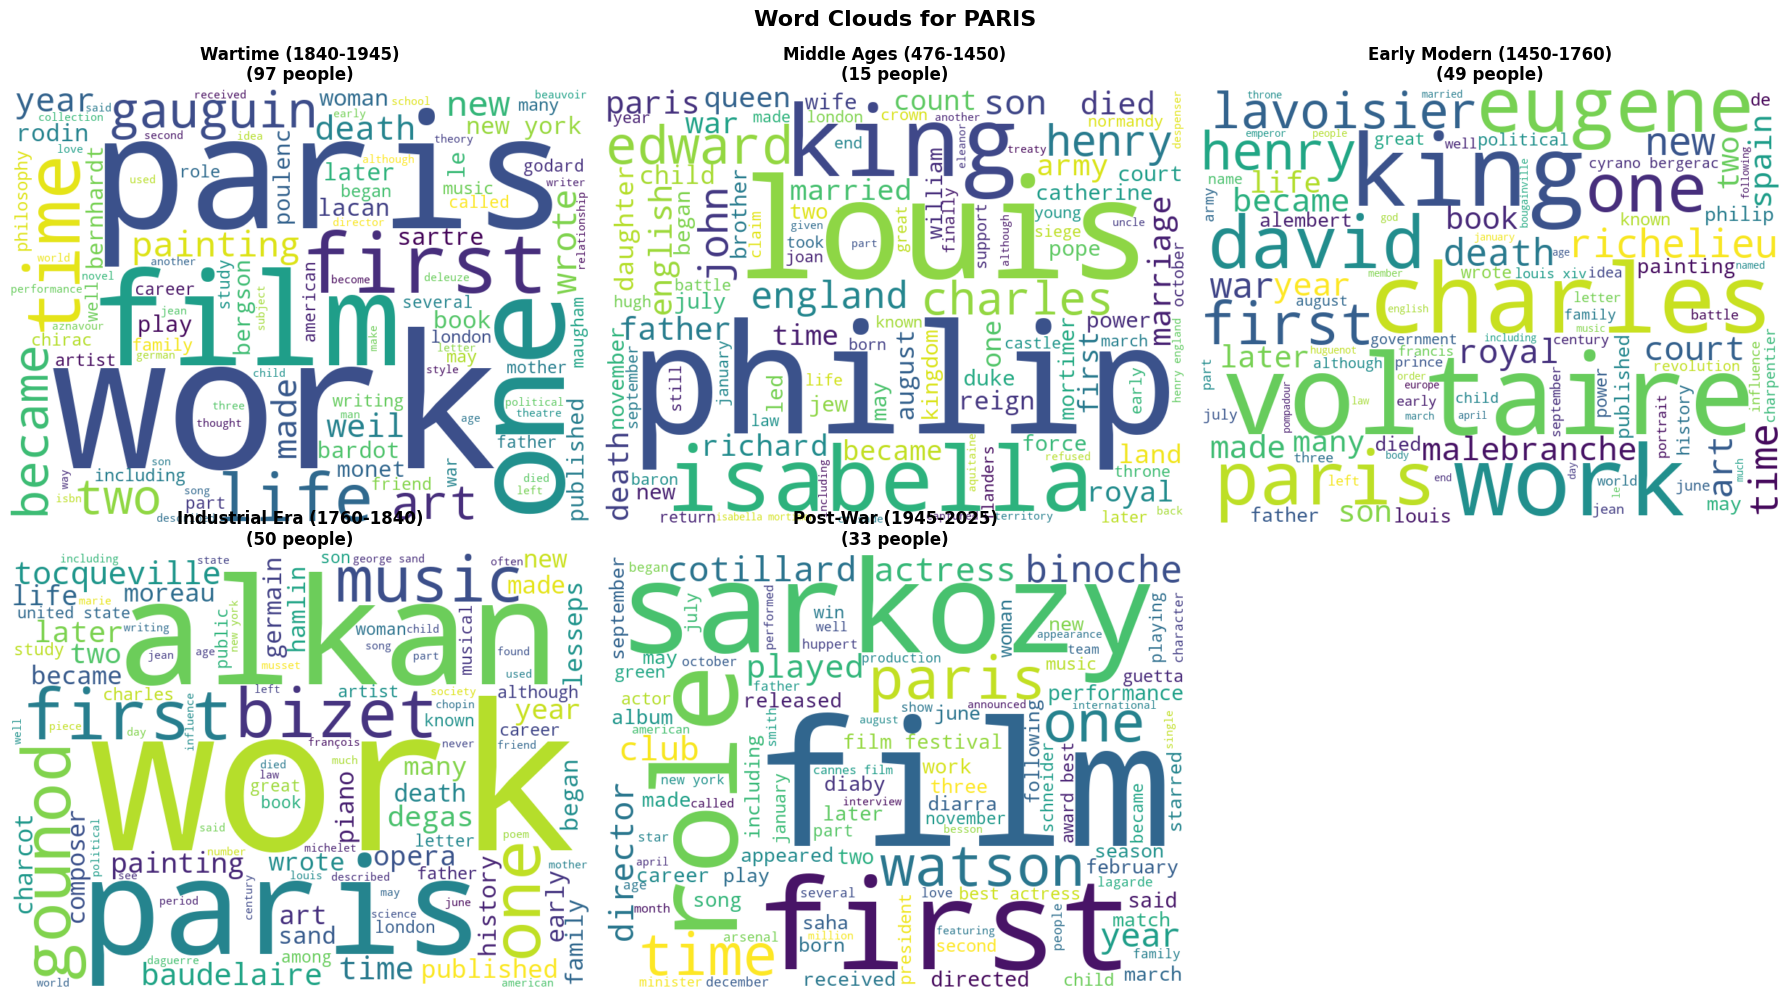


Processing City 3: LOS ANGELES

  Era: Post-War (1945-2025) (157 people)
  Fetched content for 156/157 people (1 errors)

  Era: Wartime (1840-1945) (33 people)
  Fetched content for 33/33 people (0 errors)


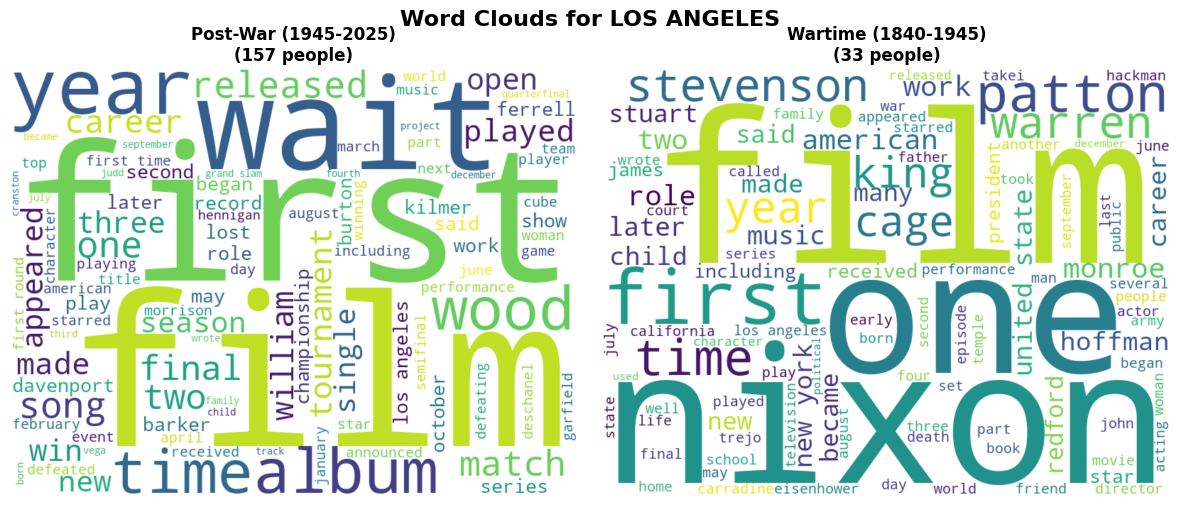

In [49]:
# Get top 3 cities by number of people
top_3_cities = top_cities[:3]

print("Top 3 cities for wordcloud analysis:")
for i, (city, people) in enumerate(top_3_cities, 1):
    print(f"{i}. {city}: {len(people)} people")

def get_combined_content(people_list, network):
    combined_content = []
    errors = 0
    
    for person in people_list:
        try:
            wiki_link = network.nodes[person].get('Link', '')
            if wiki_link:
                # Extract page title from URL
                page_title = wiki_link.split('/wiki/')[-1]
                
                # Use Wikipedia API to get clean plain text content
                api_url = f"https://en.wikipedia.org/w/api.php?action=query&format=json&titles={page_title}&prop=extracts&explaintext=true"
                
                req = urllib.request.Request(api_url, headers={'User-Agent': "Magic Browser"}) 
                con = urllib.request.urlopen(req)
                response = con.read().decode('utf-8')
                data = json.loads(response)
                
                # Extract the text content
                pages = data['query']['pages']
                for page_id in pages:
                    if 'extract' in pages[page_id]:
                        content = pages[page_id]['extract']
                        combined_content.append(content)
                        break
                        
        except Exception as e:
            errors += 1
            continue
    
    print(f"  Fetched content for {len(combined_content)}/{len(people_list)} people ({errors} errors)")
    return ' '.join(combined_content)

# Generate wordclouds for each city and era
for city_idx, (city, all_people) in enumerate(top_3_cities, 1):
    print(f"\n{'='*80}")
    print(f"Processing City {city_idx}: {city}")
    print(f"{'='*80}")
    
    era_dict = city_era_groups[city]
    
    # Get eras that have people
    eras_with_people = [(era, people) for era, people in era_dict.items() 
                        if len(people) > 0 and era != 'Unknown']
    
    if len(eras_with_people) == 0:
        print(f"No eras with people for {city}")
        continue
    
    # Create subplots for all eras of this city
    n_eras = len(eras_with_people)
    n_cols = min(3, n_eras)
    n_rows = (n_eras + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_eras == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, (era, era_people) in enumerate(eras_with_people):
        print(f"\n  Era: {era} ({len(era_people)} people)")
        
        # Get combined Wikipedia content for all people in this era
        combined_content = get_combined_content(era_people, network)
        
        if combined_content:
            # Clean and tokenize the content
            tokens = clean_tokenize_lemmatize_nltk(combined_content)

            tokens = [token for token in tokens if token not in {'new york', 'french', 'france', 'america'}]
            
            # Create text from tokens
            text = ' '.join(tokens)
            
            if len(text) > 0:
                # Generate wordcloud
                wordcloud = WordCloud(width=800, height=600, 
                                    background_color='white',
                                    colormap='viridis',
                                    max_words=100).generate(text)
                
                # Plot
                ax = axes[idx]
                ax.imshow(wordcloud, interpolation='bilinear')
                ax.set_title(f'{era}\n({len(era_people)} people)', 
                           fontsize=12, fontweight='bold')
                ax.axis('off')
            else:
                axes[idx].text(0.5, 0.5, 'No text data', 
                             ha='center', va='center', fontsize=14)
                axes[idx].set_title(f'{era}\n({len(era_people)} people)', 
                                  fontsize=12, fontweight='bold')
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, 'No Wikipedia content', 
                         ha='center', va='center', fontsize=14)
            axes[idx].set_title(f'{era}\n({len(era_people)} people)', 
                              fontsize=12, fontweight='bold')
            axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(eras_with_people), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Word Clouds for {city}', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

I created wordclouds for various cities (like Athens or London), but I especially focused on the one from Rome since one of our main ideas was to analyse data around the popes. We chose popes initially as they are major figures across a long time, with a lot of power and connections. Also, the node with the highest betweenness centrality is Pope John Paul II.

Processing City: ROME (using full network)

  Era: Before Christ (< 30) (20 people)
  Fetched content for 20/20 people (0 errors)

  Era: Early Modern (1450-1760) (13 people)
  Fetched content for 13/13 people (0 errors)

  Era: Wartime (1840-1945) (16 people)
  Fetched content for 16/16 people (0 errors)

  Era: Post-War (1945-2025) (22 people)
  Fetched content for 22/22 people (0 errors)

  Era: Classical Era (30-476) (32 people)
  Fetched content for 32/32 people (0 errors)

  Era: Middle Ages (476-1450) (67 people)
  Fetched content for 67/67 people (0 errors)


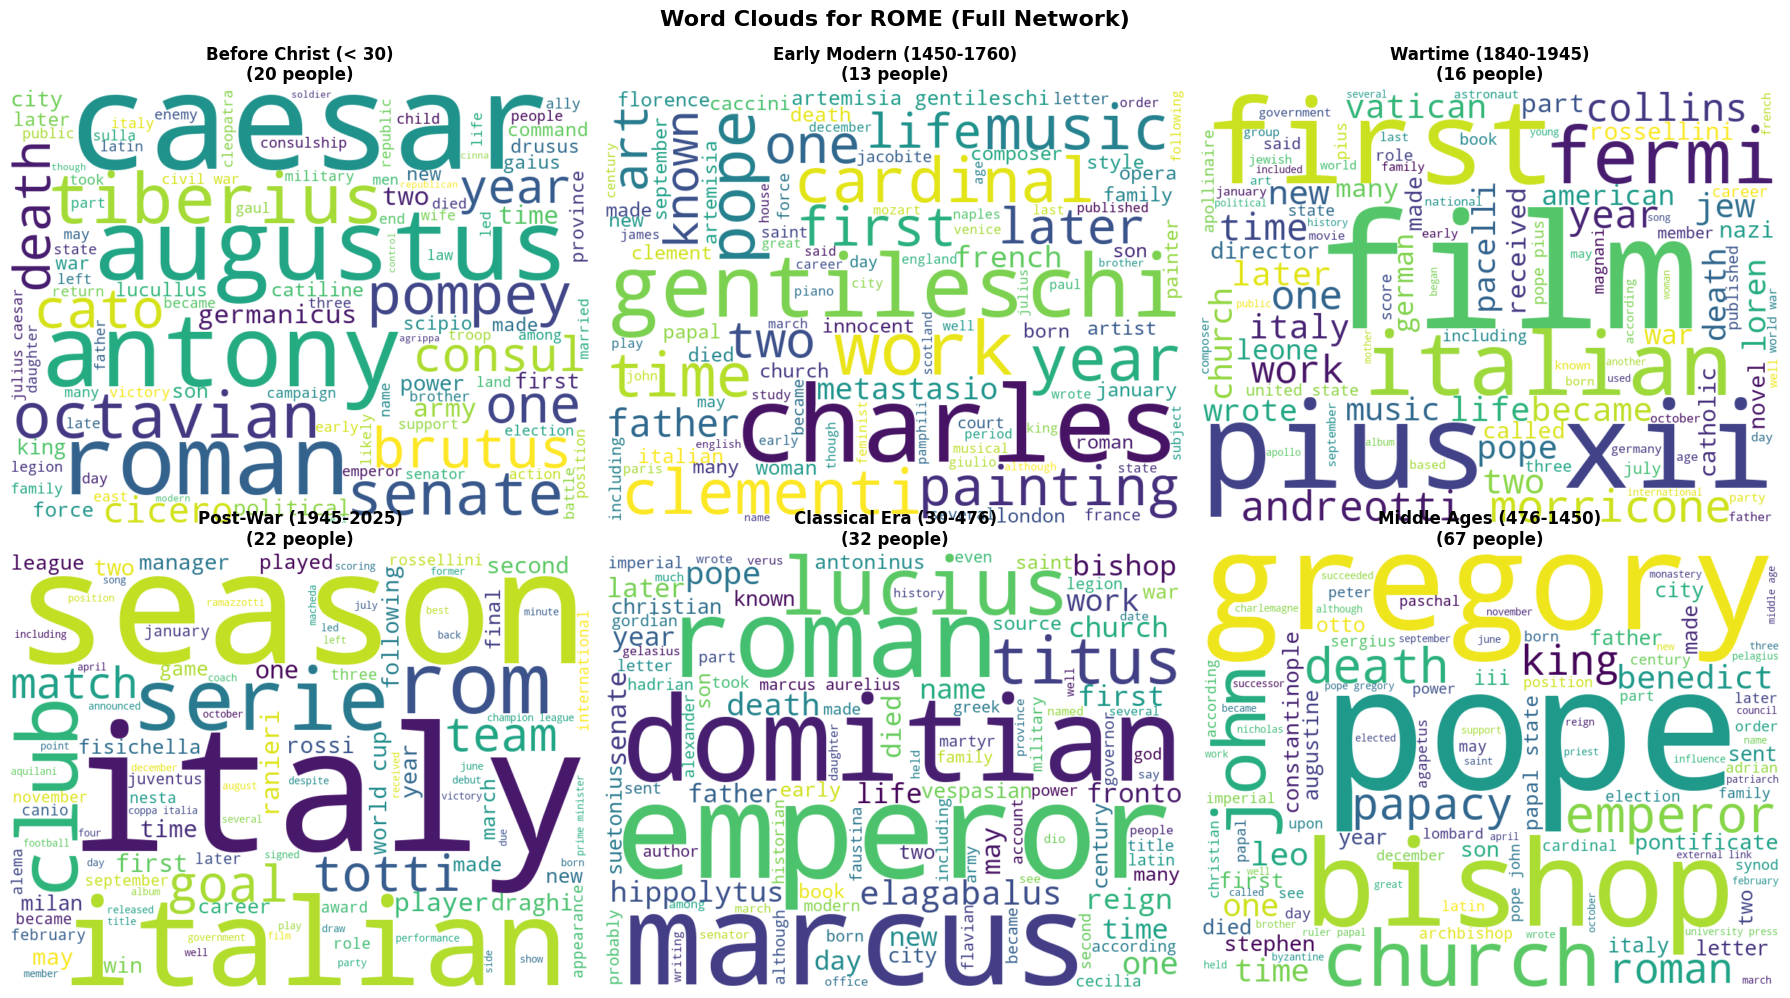

In [50]:
# Generate wordcloud for Rome using the full network
rome_data = None
for city, people in full_top_cities:
    if city == "ROME":
        rome_data = (city, people)
        break

if rome_data:
    city, all_people = rome_data
    print(f"Processing City: {city} (using full network)")
    print(f"{'='*80}")
    
    era_dict = full_city_era_groups[city]
    
    # Get eras that have people
    eras_with_people = [(era, people) for era, people in era_dict.items() 
                        if len(people) > 0 and era != 'Unknown']
    
    if len(eras_with_people) == 0:
        print(f"No eras with people for {city}")
    else:
        # Create subplots for all eras of Rome
        n_eras = len(eras_with_people)
        n_cols = min(3, n_eras)
        n_rows = (n_eras + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
        if n_eras == 1:
            axes = np.array([axes])
        axes = axes.flatten()
        
        for idx, (era, era_people) in enumerate(eras_with_people):
            print(f"\n  Era: {era} ({len(era_people)} people)")
            
            # Get combined Wikipedia content for all people in this era
            combined_content = get_combined_content(era_people, full_network)
            
            if combined_content:
                # Clean and tokenize the content
                tokens = clean_tokenize_lemmatize_nltk(combined_content)
                tokens = [token for token in tokens if token not in {'rome'}]
                
                # Create text from tokens
                text = ' '.join(tokens)
                
                if len(text) > 0:
                    # Generate wordcloud
                    wordcloud = WordCloud(width=800, height=600, 
                                        background_color='white',
                                        colormap='viridis',
                                        max_words=100).generate(text)
                    
                    # Plot
                    ax = axes[idx]
                    ax.imshow(wordcloud, interpolation='bilinear')
                    ax.set_title(f'{era}\n({len(era_people)} people)', 
                               fontsize=12, fontweight='bold')
                    ax.axis('off')
                else:
                    axes[idx].text(0.5, 0.5, 'No text data', 
                                 ha='center', va='center', fontsize=14)
                    axes[idx].set_title(f'{era}\n({len(era_people)} people)', 
                                      fontsize=12, fontweight='bold')
                    axes[idx].axis('off')
            else:
                axes[idx].text(0.5, 0.5, 'No Wikipedia content', 
                             ha='center', va='center', fontsize=14)
                axes[idx].set_title(f'{era}\n({len(era_people)} people)', 
                                  fontsize=12, fontweight='bold')
                axes[idx].axis('off')
        
        # Hide unused subplots
        for idx in range(len(eras_with_people), len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle(f'Word Clouds for {city} (Full Network)', fontsize=16, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.show()

Since the pope seems to be a constant presence in the wordclouds, I set to visualise the frequency of the word 'pope' across eras. They have the most influence in the Middle Ages, decreasing as we approach to the modern times.

Analyzing word 'pope' frequency for ROME

Era: Before Christ (< 30) (20 people)
  Fetched content for 20/20 people (0 errors)
  'pope' appears 16 times out of 55551 tokens
  Frequency: 0.29 per 1000 words

Era: Classical Era (30-476) (32 people)
  Fetched content for 32/32 people (0 errors)
  'pope' appears 167 times out of 31027 tokens
  Frequency: 5.38 per 1000 words

Era: Middle Ages (476-1450) (67 people)
  Fetched content for 67/67 people (0 errors)
  'pope' appears 804 times out of 35950 tokens
  Frequency: 22.36 per 1000 words

Era: Early Modern (1450-1760) (13 people)
  Fetched content for 13/13 people (0 errors)
  'pope' appears 135 times out of 17884 tokens
  Frequency: 7.55 per 1000 words

Era: Wartime (1840-1945) (16 people)
  Fetched content for 16/16 people (0 errors)
  'pope' appears 181 times out of 40421 tokens
  Frequency: 4.48 per 1000 words

Era: Post-War (1945-2025) (22 people)
  Fetched content for 22/22 people (0 errors)
  'pope' appears 1 times out of 37516 toke

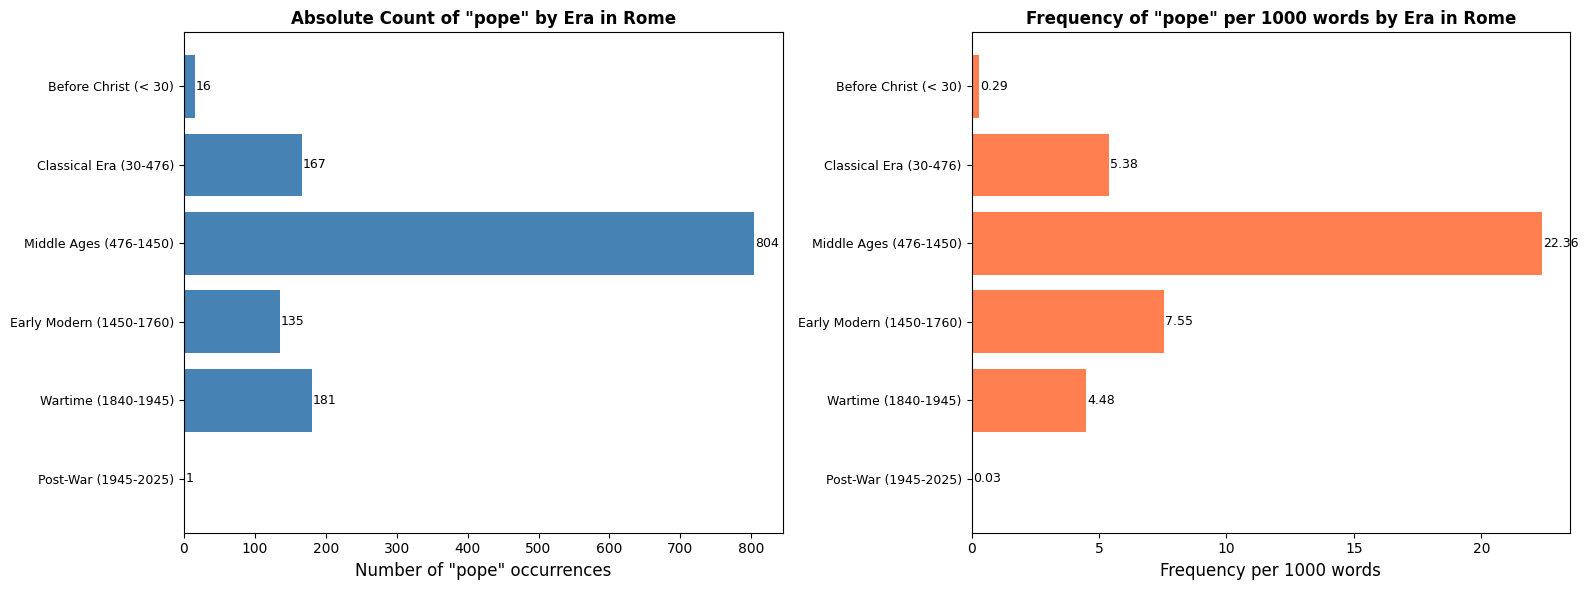


Summary Table:
Era                                 Count      Total Tokens    Per 1000  
--------------------------------------------------------------------------------
Before Christ (< 30)                16         55551           0.29      
Classical Era (30-476)              167        31027           5.38      
Middle Ages (476-1450)              804        35950           22.36     
Early Modern (1450-1760)            135        17884           7.55      
Wartime (1840-1945)                 181        40421           4.48      
Post-War (1945-2025)                1          37516           0.03      


In [51]:
# Analyze frequency of the word 'pope' through eras for Rome
rome_data = None
for city, people in full_top_cities:
    if city == "ROME":
        rome_data = (city, people)
        break

if rome_data:
    city, all_people = rome_data
    print(f"Analyzing word 'pope' frequency for {city}")
    print(f"{'='*80}")
    
    era_dict = full_city_era_groups[city]
    
    # Define chronological order
    era_order_chrono = [
        'Before Christ (< 30)',
        'Classical Era (30-476)',
        'Middle Ages (476-1450)',
        'Early Modern (1450-1760)',
        'Industrial Era (1760-1840)',
        'Wartime (1840-1945)',
        'Post-War (1945-2025)'
    ]
    
    # Get eras that have people in chronological order
    eras_with_people = [(era, era_dict[era]) for era in era_order_chrono 
                        if era in era_dict and len(era_dict[era]) > 0]
    
    pope_frequencies = []
    
    for era, era_people in eras_with_people:
        print(f"\nEra: {era} ({len(era_people)} people)")
        
        # Get combined Wikipedia content for all people in this era
        combined_content = get_combined_content(era_people, full_network)
        
        if combined_content:
            # Clean and tokenize the content
            tokens = clean_tokenize_lemmatize_nltk(combined_content)
            
            # Count total tokens and 'pope' occurrences
            total_tokens = len(tokens)
            pope_count = tokens.count('pope')
            
            if total_tokens > 0:
                pope_freq = (pope_count / total_tokens) * 1000  # per 1000 words
                pope_frequencies.append({
                    'era': era,
                    'pope_count': pope_count,
                    'total_tokens': total_tokens,
                    'frequency_per_1000': pope_freq
                })
                print(f"  'pope' appears {pope_count} times out of {total_tokens} tokens")
                print(f"  Frequency: {pope_freq:.2f} per 1000 words")
    
    # Visualize the results
    if pope_frequencies:
        df_pope = pd.DataFrame(pope_frequencies)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot 1: Absolute count
        ax1.barh(range(len(df_pope)), df_pope['pope_count'], color='steelblue')
        ax1.set_yticks(range(len(df_pope)))
        ax1.set_yticklabels(df_pope['era'], fontsize=9)
        ax1.set_xlabel('Number of "pope" occurrences', fontsize=12)
        ax1.set_title('Absolute Count of "pope" by Era in Rome', fontsize=12, fontweight='bold')
        ax1.invert_yaxis()
        
        # Add count labels
        for i, v in enumerate(df_pope['pope_count']):
            ax1.text(v + 1, i, str(int(v)), va='center', fontsize=9)
        
        # Plot 2: Frequency per 1000 words
        ax2.barh(range(len(df_pope)), df_pope['frequency_per_1000'], color='coral')
        ax2.set_yticks(range(len(df_pope)))
        ax2.set_yticklabels(df_pope['era'], fontsize=9)
        ax2.set_xlabel('Frequency per 1000 words', fontsize=12)
        ax2.set_title('Frequency of "pope" per 1000 words by Era in Rome', fontsize=12, fontweight='bold')
        ax2.invert_yaxis()
        
        # Add frequency labels
        for i, v in enumerate(df_pope['frequency_per_1000']):
            ax2.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary table
        print("\n" + "="*80)
        print("Summary Table:")
        print("="*80)
        print(f"{'Era':<35} {'Count':<10} {'Total Tokens':<15} {'Per 1000':<10}")
        print("-"*80)
        for _, row in df_pope.iterrows():
            print(f"{row['era']:<35} {row['pope_count']:<10} {row['total_tokens']:<15} {row['frequency_per_1000']:<10.2f}")

I continued analysing the popes, by creating a 'pope subgraph' containing the popes and their direct neighbours. I analysed betweeness centrality for popes and non-pope influential people, trying to find some interesting, less known characters.

In [55]:
# Create subgraph with Pope nodes and their direct neighbors
# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/celebrities_clean_without_content.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

# Find all nodes that contain 'Pope' in their name
pope_nodes = set()
for node in network.nodes():
    name = network.nodes[node].get('NameURL', '')
    if 'Pope' in name:
        pope_nodes.add(node)

print(f"  Found {len(pope_nodes)} nodes with 'Pope' in their name")

# Get all neighbors of Pope nodes
nodes_to_include = set(pope_nodes)
for pope_node in pope_nodes:
    neighbors = set(network.neighbors(pope_node))
    nodes_to_include.update(neighbors)

print(f"  Including {len(nodes_to_include) - len(pope_nodes)} directly connected nodes")

# Create subgraph
pope_subgraph = network.subgraph(nodes_to_include).copy()

print(f"\n✓ Pope subgraph created!")
print(f"  Original network: {network.number_of_nodes()} nodes, {network.number_of_edges()} edges")
print(f"  Pope subgraph: {pope_subgraph.number_of_nodes()} nodes, {pope_subgraph.number_of_edges()} edges")
print(f"  Pope nodes: {len(pope_nodes)}")
print(f"  Connected nodes: {len(nodes_to_include) - len(pope_nodes)}")

# Show some example Pope nodes
print("\nSample Pope nodes:")
for i, pope_node in enumerate(list(pope_nodes)[:10], 1):
    name = pope_subgraph.nodes[pope_node].get('Name', pope_node)
    birthyear = pope_subgraph.nodes[pope_node].get('birthyear', 'N/A')
    birthcity = pope_subgraph.nodes[pope_node].get('birthcity', 'N/A')
    print(f"  {i}. {name} (born {birthyear}, {birthcity})")

# Calculate betweenness centrality for the Pope subgraph
print("\nCalculating betweenness centrality for Pope subgraph...")
pope_betweenness = nx.betweenness_centrality(pope_subgraph)

# Get top 20 nodes by betweenness in the Pope subgraph
sorted_pope_bc = sorted(pope_betweenness.items(), key=lambda x: x[1], reverse=True)

print("\nTop 20 Nodes by Betweenness Centrality (in Pope subgraph):")
print("=" * 120)
print(f"{'Rank':<6} {'Name':<50} {'Betweenness':<15} {'Is Pope?':<10}")
print("-" * 120)

for rank, (node, bc) in enumerate(sorted_pope_bc[:20], 1):
    name = pope_subgraph.nodes[node].get('Name', node)
    is_pope = 'Yes' if node in pope_nodes else 'No'
    print(f"{rank:<6} {name:<50} {bc:<15.6f} {is_pope:<10}")

✓ Network loaded successfully!
  Nodes: 11286
  Edges: 125705
  Found 266 nodes with 'Pope' in their name
  Including 573 directly connected nodes

✓ Pope subgraph created!
  Original network: 11286 nodes, 125705 edges
  Pope subgraph: 839 nodes, 5928 edges
  Pope nodes: 266
  Connected nodes: 573

Sample Pope nodes:
  1. Pope Donus (born 600.0, ROME)
  2. Pope Silverius (born 486.0, FROSINONE)
  3. Pope John XII (born 937.0, ROME)
  4. Pope Benedict XV (born 1854.0, GENOA)
  5. Pope Paul V (born 1552.0, ROME)
  6. Pope Pius IV (born 1499.0, MILAN)
  7. Pope Anacletus (born 1.0, ROME)
  8. Pope Honorius II (born 1080.0, PAPAL STATES)
  9. Pope Clement II (born 1005.0, HORNBURG)
  10. Pope Benedict IX (born 1012.0, ROME)

Calculating betweenness centrality for Pope subgraph...

Top 20 Nodes by Betweenness Centrality (in Pope subgraph):
Rank   Name                                               Betweenness     Is Pope?  
--------------------------------------------------------------------

In [56]:
# Get top 20 non-Pope nodes by betweenness centrality in the Pope subgraph
non_pope_bc = [(node, bc) for node, bc in sorted_pope_bc if node not in pope_nodes]

print("\nTop 20 Non-Pope Nodes by Betweenness Centrality (in Pope subgraph):")
print("=" * 120)
print(f"{'Rank':<6} {'Name':<50} {'Betweenness':<15} {'Occupation':<30}")
print("-" * 120)

for rank, (node, bc) in enumerate(non_pope_bc[:20], 1):
    name = pope_subgraph.nodes[node].get('Name', node)
    occupation = pope_subgraph.nodes[node].get('occupation', 'N/A')
    birthcity = pope_subgraph.nodes[node].get('birthcity', 'N/A')
    print(f"{rank:<6} {name:<50} {bc:<15.6f} {occupation:<30}")


Top 20 Non-Pope Nodes by Betweenness Centrality (in Pope subgraph):
Rank   Name                                               Betweenness     Occupation                    
------------------------------------------------------------------------------------------------------------------------
1      Charlemagne                                        0.066087        POLITICIAN                    
2      Saint Peter                                        0.052902        RELIGIOUS FIGURE              
3      Augustine of Hippo                                 0.048933        PHILOSOPHER                   
4      Thomas Aquinas                                     0.046303        PHILOSOPHER                   
5      Bede                                               0.032960        HISTORIAN                     
6      Jesus Christ                                       0.031965        RELIGIOUS FIGURE              
7      Constantine I                                      0.030407        P

In [57]:
# Find which non-Pope node is connected to the most Pope nodes
print("Finding nodes connected to the most Popes:")
print("=" * 120)

# For each non-Pope node, count how many Pope nodes it's connected to
non_pope_connections = {}

for node in pope_subgraph.nodes():
    if node not in pope_nodes:
        # Count connections to Pope nodes
        pope_connections = sum(1 for neighbor in pope_subgraph.neighbors(node) if neighbor in pope_nodes)
        if pope_connections > 0:
            non_pope_connections[node] = pope_connections

# Sort by number of Pope connections
sorted_connections = sorted(non_pope_connections.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'Rank':<6} {'Name':<50} {'Pope Connections':<18} {'Occupation':<30}")
print("-" * 120)

for rank, (node, pope_conn) in enumerate(sorted_connections[:20], 1):
    name = pope_subgraph.nodes[node].get('Name', node)
    occupation = pope_subgraph.nodes[node].get('occupation', 'N/A')
    birthcity = pope_subgraph.nodes[node].get('birthcity', 'N/A')
    print(f"{rank:<6} {name:<50} {pope_conn:<18} {occupation:<30}")

# Check if any node is connected to ALL Popes
if sorted_connections:
    top_node, max_connections = sorted_connections[0]
    top_name = pope_subgraph.nodes[top_node].get('Name', top_node)
    print(f"\n{'='*120}")
    print(f"Total Pope nodes: {len(pope_nodes)}")
    print(f"Most connected node: {top_name} with {max_connections} Pope connections")
    print(f"Connected to all Popes? {'Yes' if max_connections == len(pope_nodes) else 'No'}")

Finding nodes connected to the most Popes:

Rank   Name                                               Pope Connections   Occupation                    
------------------------------------------------------------------------------------------------------------------------
1      Anselm of Canterbury                               10                 RELIGIOUS FIGURE              
2      Bernard of Clairvaux                               10                 RELIGIOUS FIGURE              
3      Thomas Aquinas                                     10                 PHILOSOPHER                   
4      Charles I of Naples                                9                  POLITICIAN                    
5      Robert Bellarmine                                  9                  PHYSICIAN                     
6      John of the Cross                                  8                  RELIGIOUS FIGURE              
7      Henry II, Holy Roman Emperor                       8                  PO

I had an idea to check if popes are bridges between communities, however this was incorrect. However it took me on the path of analysing people that are critical bridges - if they are removed from the network they will separate a whole group of people from the main network.

ANALYZING: Do Popes Act as Bridges Between Historical Communities?

Found 266 Pope nodes

Network without Popes:
  Nodes: 11020
  Edges: 101115
  Connected components: 236

Communities detected (without Popes): 256

Top 5 Communities (without Popes):

  Community 1: 2035 members
    Top eras: [('Wartime (1840-1945)', 1407), ('Post-War (1945-2025)', 573), ('Industrial Era (1760-1840)', 52)]
    Top occupations: [('POLITICIAN', 1218), ('MILITARY PERSONNEL', 116), ('WRITER', 86)]
    Top cities: [('NEW YORK', 38), ('MOSCOW', 30), ('LONDON', 28)]

  Community 2: 1759 members
    Top eras: [('Middle Ages (476-1450)', 659), ('Before Christ (< 30)', 434), ('Early Modern (1450-1760)', 348)]
    Top occupations: [('POLITICIAN', 843), ('RELIGIOUS FIGURE', 205), ('WRITER', 137)]
    Top cities: [('OTHER', 390), ('ISTANBUL', 50), ('ROME', 35)]

  Community 3: 1739 members
    Top eras: [('Wartime (1840-1945)', 686), ('Industrial Era (1760-1840)', 499), ('Early Modern (1450-1760)', 412)]
    Top oc

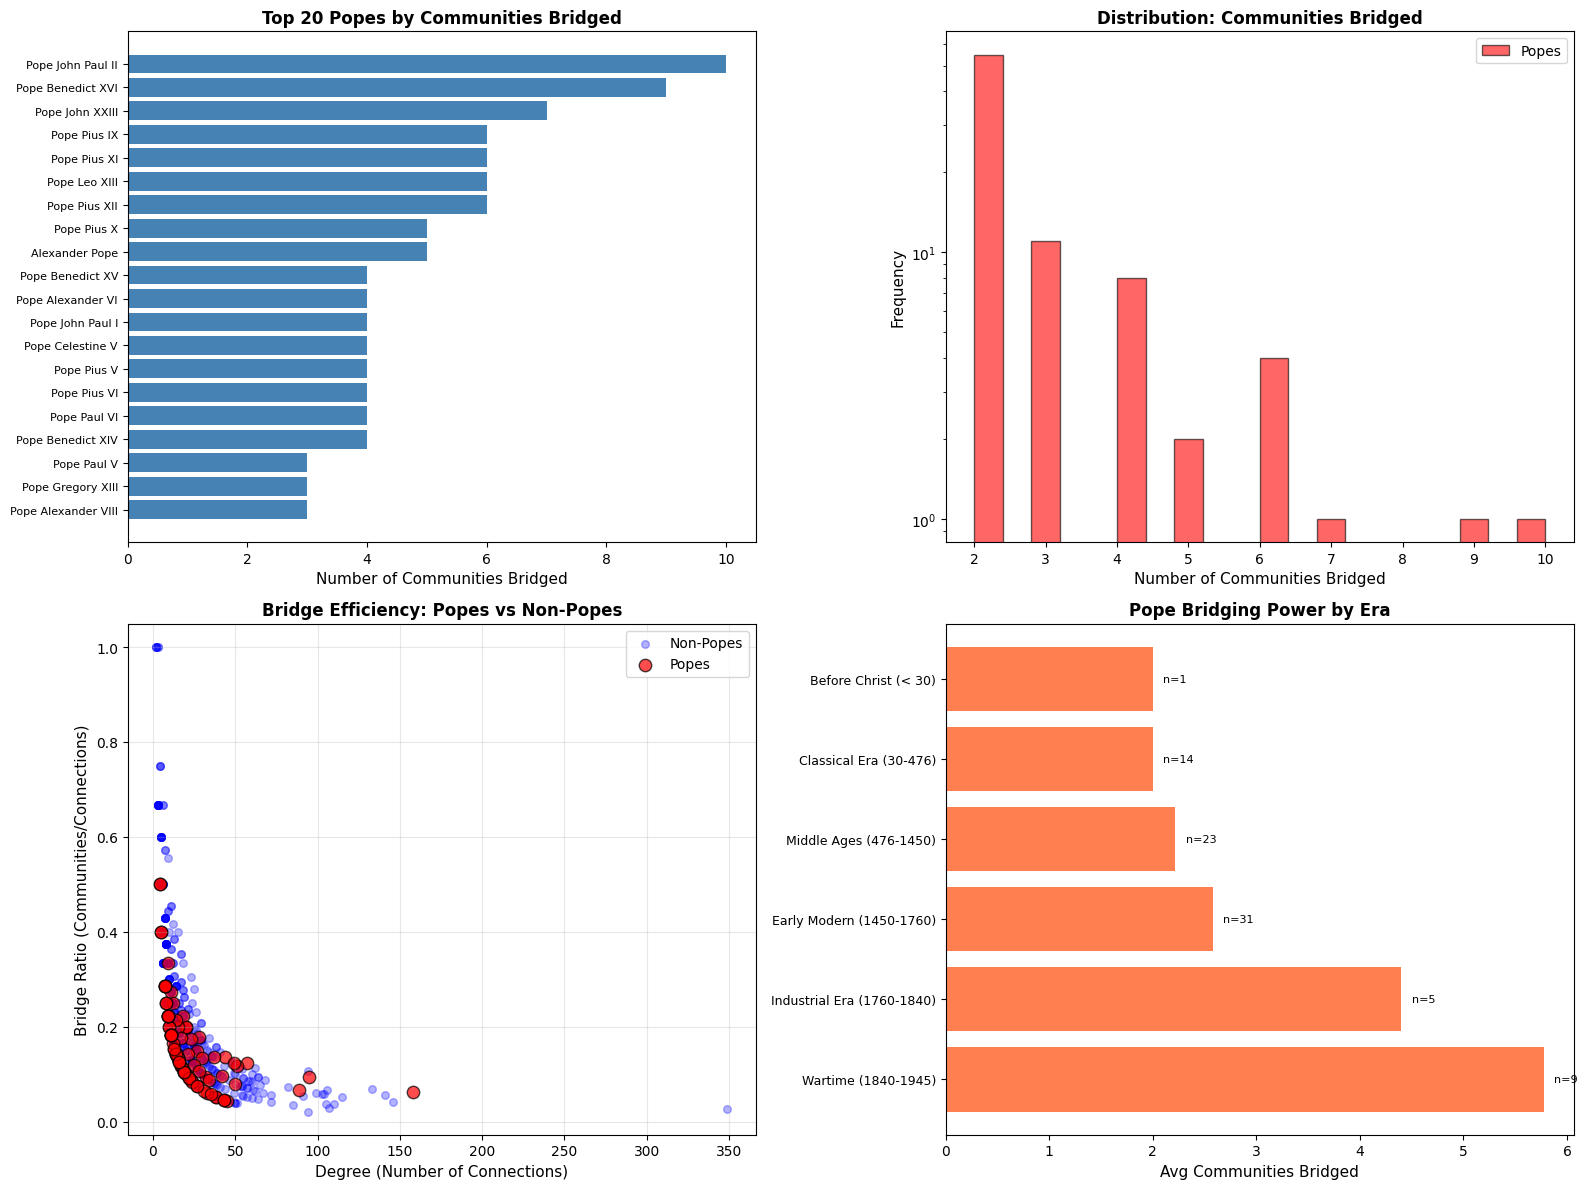

In [58]:
# Step 1: Detect communities in the full network (excluding Popes first)
print("="*100)
print("ANALYZING: Do Popes Act as Bridges Between Historical Communities?")
print("="*100)

# Find all Pope nodes
pope_nodes = set()
for node in network.nodes():
    name = network.nodes[node].get('NameURL', '')
    if 'Pope' in name:
        pope_nodes.add(node)

print(f"\nFound {len(pope_nodes)} Pope nodes")

# Step 2: Create UNDIRECTED network WITHOUT Popes
non_pope_network = network.to_undirected()
non_pope_network.remove_nodes_from(pope_nodes)

print(f"\nNetwork without Popes:")
print(f"  Nodes: {non_pope_network.number_of_nodes()}")
print(f"  Edges: {non_pope_network.number_of_edges()}")

# Check connectivity
num_components_without_popes = nx.number_connected_components(non_pope_network)
print(f"  Connected components: {num_components_without_popes}")

# Step 3: Detect communities in non-Pope network
from collections import Counter
from networkx.algorithms import community

communities_without_popes = list(community.louvain_communities(non_pope_network))
print(f"\nCommunities detected (without Popes): {len(communities_without_popes)}")

# Analyze top communities
print("\nTop 5 Communities (without Popes):")
for i, comm in enumerate(sorted(communities_without_popes, key=len, reverse=True)[:5], 1):
    print(f"\n  Community {i}: {len(comm)} members")
    
    # Dominant eras
    eras = [get_era(network.nodes[node].get('birthyear')) for node in comm]
    era_counts = Counter(eras)
    print(f"    Top eras: {era_counts.most_common(3)}")
    
    # Dominant occupations
    occupations = [network.nodes[node].get('occupation', 'Unknown') for node in comm]
    occ_counts = Counter(occupations)
    print(f"    Top occupations: {occ_counts.most_common(3)}")
    
    # Dominant cities
    cities = [network.nodes[node].get('birthcity', 'Unknown') for node in comm]
    city_counts = Counter(cities)
    print(f"    Top cities: {city_counts.most_common(3)}")

# Step 4: Now analyze WITH Popes - do they connect these communities?
print("\n" + "="*100)
print("MEASURING POPE BRIDGING EFFECT")
print("="*100)

# Convert full network to undirected for neighbor analysis
network_undirected = network.to_undirected()

# For each Pope, count how many different communities they connect
pope_bridge_scores = []

for pope in pope_nodes:
    # Get neighbors of this Pope from undirected network
    neighbors = set(network_undirected.neighbors(pope))
    
    # Find which communities these neighbors belong to
    connected_communities = set()
    for neighbor in neighbors:
        for i, comm in enumerate(communities_without_popes):
            if neighbor in comm:
                connected_communities.add(i)
                break
    
    pope_name = network.nodes[pope].get('Name', pope)
    pope_era = get_era(network.nodes[pope].get('birthyear'))
    num_connections = len(neighbors)
    num_communities_bridged = len(connected_communities)
    
    if num_communities_bridged > 1:  # Only count if bridging at least 2 communities
        pope_bridge_scores.append({
            'name': pope_name,
            'era': pope_era,
            'degree': num_connections,
            'communities_bridged': num_communities_bridged,
            'bridge_ratio': num_communities_bridged / num_connections if num_connections > 0 else 0
        })

# Sort by communities bridged
pope_bridge_scores.sort(key=lambda x: x['communities_bridged'], reverse=True)

print(f"\nTop 20 Popes by Number of Communities Bridged:")
print("-"*100)
print(f"{'Rank':<6} {'Name':<45} {'Era':<25} {'Degree':<10} {'Communities':<12}")
print("-"*100)

for rank, pope in enumerate(pope_bridge_scores[:20], 1):
    print(f"{rank:<6} {pope['name']:<45} {pope['era']:<25} {pope['degree']:<10} {pope['communities_bridged']:<12}")

# Step 5: Statistical analysis - Are Popes better bridges than non-Popes?
print("\n" + "="*100)
print("STATISTICAL COMPARISON: Popes vs Non-Popes as Bridges")
print("="*100)

# Calculate bridging scores for non-Popes too
non_pope_bridge_scores = []

for node in network_undirected.nodes():
    if node not in pope_nodes:
        neighbors = set(network_undirected.neighbors(node))
        
        connected_communities = set()
        for neighbor in neighbors:
            for i, comm in enumerate(communities_without_popes):
                if neighbor in comm:
                    connected_communities.add(i)
                    break
        
        num_connections = len(neighbors)
        num_communities_bridged = len(connected_communities)
        
        if num_connections > 0 and num_communities_bridged > 1:
            non_pope_bridge_scores.append({
                'degree': num_connections,
                'communities_bridged': num_communities_bridged,
                'bridge_ratio': num_communities_bridged / num_connections
            })

# Compare statistics
pope_avg_communities = np.mean([p['communities_bridged'] for p in pope_bridge_scores])
pope_avg_ratio = np.mean([p['bridge_ratio'] for p in pope_bridge_scores])

non_pope_avg_communities = np.mean([p['communities_bridged'] for p in non_pope_bridge_scores])
non_pope_avg_ratio = np.mean([p['bridge_ratio'] for p in non_pope_bridge_scores])

print(f"\nPopes:")
print(f"  Average communities bridged: {pope_avg_communities:.2f}")
print(f"  Average bridge ratio: {pope_avg_ratio:.4f}")
print(f"  Sample size: {len(pope_bridge_scores)}")

print(f"\nNon-Popes:")
print(f"  Average communities bridged: {non_pope_avg_communities:.2f}")
print(f"  Average bridge ratio: {non_pope_avg_ratio:.4f}")
print(f"  Sample size: {len(non_pope_bridge_scores)}")

print(f"\nDifference:")
print(f"  Popes bridge {(pope_avg_communities/non_pope_avg_communities - 1)*100:.1f}% more communities on average")

# Step 6: Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Communities bridged by top Popes
ax1 = axes[0, 0]
top_20_popes = pope_bridge_scores[:20]
y_pos = range(len(top_20_popes))
ax1.barh(y_pos, [p['communities_bridged'] for p in top_20_popes], color='steelblue')
ax1.set_yticks(y_pos)
ax1.set_yticklabels([p['name'][:30] for p in top_20_popes], fontsize=8)
ax1.set_xlabel('Number of Communities Bridged', fontsize=11)
ax1.set_title('Top 20 Popes by Communities Bridged', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Plot 2: Distribution comparison
ax2 = axes[0, 1]
pope_communities_list = [p['communities_bridged'] for p in pope_bridge_scores]
non_pope_communities_list = [p['communities_bridged'] for p in non_pope_bridge_scores]

ax2.hist(pope_communities_list, bins=20, alpha=0.6, label='Popes', color='red', edgecolor='black')
ax2.set_xlabel('Number of Communities Bridged', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution: Communities Bridged', fontsize=12, fontweight='bold')
ax2.legend()
ax2.set_yscale('log')

# Plot 3: Bridge ratio by degree (scatter)
ax3 = axes[1, 0]
ax3.scatter([p['degree'] for p in non_pope_bridge_scores[:500]], 
           [p['bridge_ratio'] for p in non_pope_bridge_scores[:500]], 
           alpha=0.3, s=30, label='Non-Popes', color='blue')
ax3.scatter([p['degree'] for p in pope_bridge_scores], 
           [p['bridge_ratio'] for p in pope_bridge_scores], 
           alpha=0.7, s=80, label='Popes', color='red', edgecolors='black')
ax3.set_xlabel('Degree (Number of Connections)', fontsize=11)
ax3.set_ylabel('Bridge Ratio (Communities/Connections)', fontsize=11)
ax3.set_title('Bridge Efficiency: Popes vs Non-Popes', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Popes bridging over time (by era)
ax4 = axes[1, 1]
era_bridge_data = defaultdict(list)
for pope in pope_bridge_scores:
    era_bridge_data[pope['era']].append(pope['communities_bridged'])

era_avgs = []
for era in era_order_display:
    if era in era_bridge_data:
        era_avgs.append({
            'era': era,
            'avg_bridged': np.mean(era_bridge_data[era]),
            'count': len(era_bridge_data[era])
        })

if era_avgs:
    y_pos = range(len(era_avgs))
    ax4.barh(y_pos, [e['avg_bridged'] for e in era_avgs], color='coral')
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels([e['era'] for e in era_avgs], fontsize=9)
    ax4.set_xlabel('Avg Communities Bridged', fontsize=11)
    ax4.set_title('Pope Bridging Power by Era', fontsize=12, fontweight='bold')
    ax4.invert_yaxis()
    
    for i, e in enumerate(era_avgs):
        ax4.text(e['avg_bridged'] + 0.1, i, f"n={e['count']}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

As the hypothesis was wrong, I wanted to see which ocupations are indeed most likely to bridge communities. I believe an interesting finding here is that the presenters are the most likely to bridge communities, not politicians as I was expecting.

WHICH OCCUPATIONS ARE THE BEST BRIDGES?

Top 20 Occupations by Average Communities Bridged:
------------------------------------------------------------------------------------------------------------------------
Rank   Occupation                          Count    Avg Comm     Max Comm     Avg Ratio   
------------------------------------------------------------------------------------------------------------------------
1      PRESENTER                           15       5.13         9            0.1891      
2      BOXER                               11       4.64         10           0.2604      
3      DANCER                              11       4.27         5            0.3425      
4      FILM DIRECTOR                       166      3.88         9            0.1627      
5      FASHION DESIGNER                    10       3.80         5            0.1841      
6      PHOTOGRAPHER                        10       3.80         6            0.3504      
7      PRODUCER              

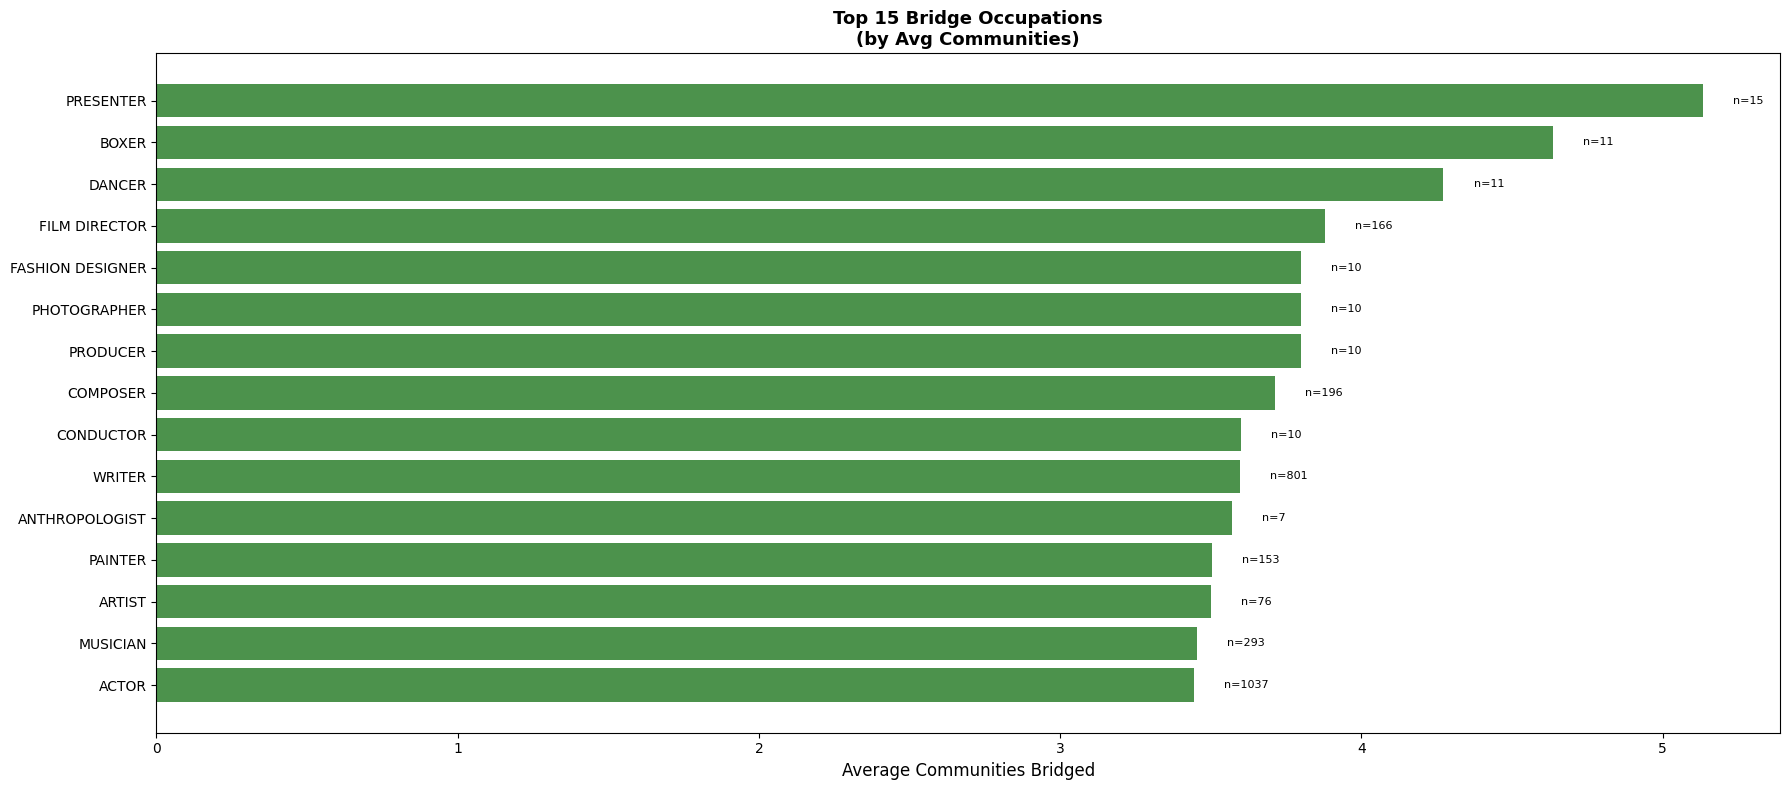


COMPARISON: Top Occupation vs Popes

Top Bridging Occupation: PRESENTER
  Average communities bridged: 5.13
  Average bridge ratio: 0.1891
  Sample size: 15

Popes:
  Average communities bridged: 2.83
  Average bridge ratio: 0.1620
  Sample size: 83

PRESENTERs bridge +81.3% communities compared to Popes


In [61]:
# Find top bridging occupations
print("="*100)
print("WHICH OCCUPATIONS ARE THE BEST BRIDGES?")
print("="*100)

# Collect bridging data by occupation
occupation_bridge_data = defaultdict(list)

for node in network_undirected.nodes():
    neighbors = set(network_undirected.neighbors(node))
    
    connected_communities = set()
    for neighbor in neighbors:
        for i, comm in enumerate(communities_without_popes):
            if neighbor in comm:
                connected_communities.add(i)
                break
    
    num_connections = len(neighbors)
    num_communities_bridged = len(connected_communities)
    
    if num_connections > 0 and num_communities_bridged > 1:
        occupation = network.nodes[node].get('occupation', 'Unknown')
        occupation_bridge_data[occupation].append({
            'degree': num_connections,
            'communities_bridged': num_communities_bridged,
            'bridge_ratio': num_communities_bridged / num_connections
        })

# Calculate statistics per occupation
occupation_stats = []

for occupation, bridges in occupation_bridge_data.items():
    if len(bridges) >= 5:  # Only occupations with at least 5 bridging members
        occupation_stats.append({
            'occupation': occupation,
            'count': len(bridges),
            'avg_communities': np.mean([b['communities_bridged'] for b in bridges]),
            'avg_ratio': np.mean([b['bridge_ratio'] for b in bridges]),
            'max_communities': max([b['communities_bridged'] for b in bridges]),
            'median_communities': np.median([b['communities_bridged'] for b in bridges])
        })

# Sort by average communities bridged
occupation_stats.sort(key=lambda x: x['avg_communities'], reverse=True)

print(f"\nTop 20 Occupations by Average Communities Bridged:")
print("-"*120)
print(f"{'Rank':<6} {'Occupation':<35} {'Count':<8} {'Avg Comm':<12} {'Max Comm':<12} {'Avg Ratio':<12}")
print("-"*120)

for rank, occ in enumerate(occupation_stats[:20], 1):
    print(f"{rank:<6} {occ['occupation']:<35} {occ['count']:<8} {occ['avg_communities']:<12.2f} {occ['max_communities']:<12} {occ['avg_ratio']:<12.4f}")

# Visualization: Top 15 occupations
fig, ax1 = plt.subplots(1, 1, figsize=(18, 8))  # Changed 'axes' to 'ax1'

# Plot 1: Average communities bridged
top_15_occs = occupation_stats[:15]
y_pos = range(len(top_15_occs))
ax1.barh(y_pos, [o['avg_communities'] for o in top_15_occs], color='darkgreen', alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([o['occupation'][:30] for o in top_15_occs], fontsize=10)
ax1.set_xlabel('Average Communities Bridged', fontsize=12)
ax1.set_title('Top 15 Bridge Occupations\n(by Avg Communities)', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Add count labels
for i, occ in enumerate(top_15_occs):
    ax1.text(occ['avg_communities'] + 0.1, i, f"n={occ['count']}", va='center', fontsize=8)
plt.tight_layout()
plt.show()

# Compare top occupation to Popes
if pope_bridge_scores:
    top_occupation = occupation_stats[0]
    print(f"\n" + "="*100)
    print(f"COMPARISON: Top Occupation vs Popes")
    print("="*100)
    print(f"\nTop Bridging Occupation: {top_occupation['occupation']}")
    print(f"  Average communities bridged: {top_occupation['avg_communities']:.2f}")
    print(f"  Average bridge ratio: {top_occupation['avg_ratio']:.4f}")
    print(f"  Sample size: {top_occupation['count']}")
    
    print(f"\nPopes:")
    print(f"  Average communities bridged: {pope_avg_communities:.2f}")
    print(f"  Average bridge ratio: {pope_avg_ratio:.4f}")
    print(f"  Sample size: {len(pope_bridge_scores)}")
    
    diff = ((top_occupation['avg_communities'] / pope_avg_communities) - 1) * 100
    print(f"\n{top_occupation['occupation']}s bridge {diff:+.1f}% communities compared to Popes")

I set out to find out if there are any communities that become disconnected if the popes are removed from the network, however the results contain 1 person communities, which are not really relevant.

In [63]:
# Find communities that are bridged primarily by Popes
print("="*100)
print("WHICH COMMUNITIES DO POPES PRIMARILY BRIDGE?")
print("="*100)

# For each pair of communities, count how many Popes vs non-Popes bridge them
from itertools import combinations

community_pair_bridges = defaultdict(lambda: {'pope_bridges': 0, 'non_pope_bridges': 0, 'total_bridges': 0})

# Check all nodes
for node in network_undirected.nodes():
    neighbors = set(network_undirected.neighbors(node))
    
    # Find which communities the neighbors belong to
    neighbor_communities = set()
    for neighbor in neighbors:
        for i, comm in enumerate(communities_without_popes):
            if neighbor in comm:
                neighbor_communities.add(i)
                break
    
    # If this node bridges at least 2 communities
    if len(neighbor_communities) >= 2:
        is_pope = node in pope_nodes
        
        # Count bridges between each pair of communities
        for comm1, comm2 in combinations(sorted(neighbor_communities), 2):
            pair_key = (comm1, comm2)
            community_pair_bridges[pair_key]['total_bridges'] += 1
            if is_pope:
                community_pair_bridges[pair_key]['pope_bridges'] += 1
            else:
                community_pair_bridges[pair_key]['non_pope_bridges'] += 1

# Find community pairs where Popes are dominant bridges
pope_dominated_pairs = []

for (comm1, comm2), counts in community_pair_bridges.items():
    if counts['total_bridges'] >= 5:  # At least 5 total bridges
        pope_ratio = counts['pope_bridges'] / counts['total_bridges']
        if pope_ratio >= 0.3:  # Popes account for 30%+ of bridges
            pope_dominated_pairs.append({
                'comm1': comm1,
                'comm2': comm2,
                'pope_bridges': counts['pope_bridges'],
                'non_pope_bridges': counts['non_pope_bridges'],
                'total_bridges': counts['total_bridges'],
                'pope_ratio': pope_ratio
            })

# Sort by Pope ratio
pope_dominated_pairs.sort(key=lambda x: x['pope_ratio'], reverse=True)

print(f"\nCommunity Pairs Where Popes Are Primary Bridges (≥30% Pope bridges):")
print("-"*120)
print(f"{'Rank':<6} {'Comm 1':<10} {'Comm 2':<10} {'Pope Bridges':<15} {'Non-Pope':<15} {'Total':<10} {'Pope %':<10}")
print("-"*120)

for rank, pair in enumerate(pope_dominated_pairs[:20], 1):
    print(f"{rank:<6} {pair['comm1']:<10} {pair['comm2']:<10} {pair['pope_bridges']:<15} "
          f"{pair['non_pope_bridges']:<15} {pair['total_bridges']:<10} {pair['pope_ratio']*100:<10.1f}")

# Analyze the top Pope-dominated community pair
if pope_dominated_pairs:
    print(f"\n" + "="*100)
    print("ANALYZING TOP POPE-BRIDGED COMMUNITY PAIR")
    print("="*100)
    
    top_pair = pope_dominated_pairs[0]
    comm1_idx = top_pair['comm1']
    comm2_idx = top_pair['comm2']
    
    # Get the actual communities
    all_communities_sorted = sorted(communities_without_popes, key=len, reverse=True)
    comm1 = all_communities_sorted[comm1_idx]
    comm2 = all_communities_sorted[comm2_idx]
    
    print(f"\nCommunity {comm1_idx} ({len(comm1)} members):")
    # Analyze community 1
    eras1 = [get_era(network.nodes[node].get('birthyear')) for node in comm1]
    era_counts1 = Counter(eras1)
    print(f"  Top eras: {era_counts1.most_common(3)}")
    
    occupations1 = [network.nodes[node].get('occupation', 'Unknown') for node in comm1]
    occ_counts1 = Counter(occupations1)
    print(f"  Top occupations: {occ_counts1.most_common(3)}")
    
    cities1 = [network.nodes[node].get('birthcity', 'Unknown') for node in comm1]
    city_counts1 = Counter(cities1)
    print(f"  Top cities: {city_counts1.most_common(3)}")
    
    print(f"\nCommunity {comm2_idx} ({len(comm2)} members):")
    # Analyze community 2
    eras2 = [get_era(network.nodes[node].get('birthyear')) for node in comm2]
    era_counts2 = Counter(eras2)
    print(f"  Top eras: {era_counts2.most_common(3)}")
    
    occupations2 = [network.nodes[node].get('occupation', 'Unknown') for node in comm2]
    occ_counts2 = Counter(occupations2)
    print(f"  Top occupations: {occ_counts2.most_common(3)}")
    
    cities2 = [network.nodes[node].get('birthcity', 'Unknown') for node in comm2]
    city_counts2 = Counter(cities2)
    print(f"  Top cities: {city_counts2.most_common(3)}")
    
    # Find which Popes bridge these two communities
    bridging_popes = []
    for pope in pope_nodes:
        neighbors = set(network_undirected.neighbors(pope))
        
        has_comm1_neighbor = any(n in comm1 for n in neighbors)
        has_comm2_neighbor = any(n in comm2 for n in neighbors)
        
        if has_comm1_neighbor and has_comm2_neighbor:
            pope_name = network.nodes[pope].get('Name', pope)
            pope_era = get_era(network.nodes[pope].get('birthyear'))
            bridging_popes.append({'name': pope_name, 'era': pope_era})
    

WHICH COMMUNITIES DO POPES PRIMARILY BRIDGE?

Community Pairs Where Popes Are Primary Bridges (≥30% Pope bridges):
------------------------------------------------------------------------------------------------------------------------
Rank   Comm 1     Comm 2     Pope Bridges    Non-Pope        Total      Pope %    
------------------------------------------------------------------------------------------------------------------------
1      64         65         5               0               5          100.0     
2      64         143        5               0               5          100.0     
3      64         178        5               0               5          100.0     
4      64         249        5               0               5          100.0     

ANALYZING TOP POPE-BRIDGED COMMUNITY PAIR

Community 64 (1 members):
  Top eras: [('Industrial Era (1760-1840)', 1)]
  Top occupations: [('POLITICIAN', 1)]
  Top cities: [('OSTEND', 1)]

Community 65 (1 members):
  Top eras: [(

In [68]:
exclusive_pope_pairs = [p for p in pope_dominated_pairs if p['pope_ratio'] == 1.0]
print(f"\n✓ Found {len(exclusive_pope_pairs)} community pairs EXCLUSIVELY bridged by Popes (100%)")


✓ Found 4 community pairs EXCLUSIVELY bridged by Popes (100%)


In [69]:
# Check if removing Popes creates isolated communities
print("="*100)
print("CHECKING IF POPES CREATE ISOLATION WHEN REMOVED")
print("="*100)

# 1. Start with the full undirected network
full_network = network.to_undirected()

# 2. Find connected components WITH Popes
components_with_popes = list(nx.connected_components(full_network))
num_components_with = len(components_with_popes)

print(f"\nWith Popes:")
print(f"  Connected components: {num_components_with}")
print(f"  Largest component size: {len(max(components_with_popes, key=len))}")

# 3. Remove Popes and check again
network_without_popes = full_network.copy()
network_without_popes.remove_nodes_from(pope_nodes)

components_without_popes = list(nx.connected_components(network_without_popes))
num_components_without = len(components_without_popes)

print(f"\nWithout Popes:")
print(f"  Connected components: {num_components_without}")
print(f"  Largest component size: {len(max(components_without_popes, key=len))}")

# 4. Calculate the increase in isolation
new_components = num_components_without - num_components_with
print(f"\n✓ Removing Popes creates {new_components} additional isolated components")

if new_components > 0:
    print(f"  → This means Popes were connecting {new_components} previously connected parts!")
else:
    print(f"  → Popes don't create new isolated components")

# 5. Find which nodes become isolated (if any)
# Nodes that lose connectivity when Popes are removed
newly_isolated_nodes = set()
for component in components_without_popes:
    if len(component) == 1:
        newly_isolated_nodes.update(component)

print(f"\nNodes that become isolated: {len(newly_isolated_nodes)}")

# 6. Check if any of the exclusive Pope-bridged community pairs become disconnected
if exclusive_pope_pairs:
    print(f"\nChecking {len(exclusive_pope_pairs)} exclusively Pope-bridged community pairs:")
    
    disconnected_pairs = 0
    for pair in exclusive_pope_pairs:
        comm1_idx = pair['comm1']
        comm2_idx = pair['comm2']
        
        all_communities_sorted = sorted(communities_without_popes, key=len, reverse=True)
        comm1_nodes = all_communities_sorted[comm1_idx]
        comm2_nodes = all_communities_sorted[comm2_idx]
        
        # Pick sample nodes from each community
        sample1 = list(comm1_nodes)[0]
        sample2 = list(comm2_nodes)[0]
        
        # Check if there's a path WITHOUT Popes
        try:
            path = nx.shortest_path(network_without_popes, sample1, sample2)
            # Path exists without Popes
        except nx.NetworkXNoPath:
            disconnected_pairs += 1
    
    print(f"  → {disconnected_pairs}/{len(exclusive_pope_pairs)} pairs become completely disconnected")

CHECKING IF POPES CREATE ISOLATION WHEN REMOVED

With Popes:
  Connected components: 233
  Largest component size: 11023

Without Popes:
  Connected components: 236
  Largest component size: 10754

✓ Removing Popes creates 3 additional isolated components
  → This means Popes were connecting 3 previously connected parts!

Nodes that become isolated: 209

Checking 4 exclusively Pope-bridged community pairs:
  → 4/4 pairs become completely disconnected


In [71]:
# Detailed analysis of disconnected community pairs
if exclusive_pope_pairs and disconnected_pairs > 0:
    print(f"\n" + "="*100)
    print("DETAILED ANALYSIS: Which Communities Become Disconnected?")
    print("="*100)
    
    all_communities_sorted = sorted(communities_without_popes, key=len, reverse=True)
    
    disconnected_details = []
    
    for pair in exclusive_pope_pairs:
        comm1_idx = pair['comm1']
        comm2_idx = pair['comm2']
        
        comm1_nodes = all_communities_sorted[comm1_idx]
        comm2_nodes = all_communities_sorted[comm2_idx]
        
        # Pick sample nodes from each community
        sample1 = list(comm1_nodes)[0]
        sample2 = list(comm2_nodes)[0]
        
        # Check if there's a path WITHOUT Popes
        try:
            path = nx.shortest_path(network_without_popes, sample1, sample2)
            is_disconnected = False
        except nx.NetworkXNoPath:
            is_disconnected = True
        
        if is_disconnected:
            # Analyze both communities
            comm1 = comm1_nodes
            comm2 = comm2_nodes
            
            # Community 1 characteristics
            eras1 = [get_era(network.nodes[node].get('birthyear')) for node in comm1]
            era_counts1 = Counter(eras1)
            occupations1 = [network.nodes[node].get('occupation', 'Unknown') for node in comm1]
            occ_counts1 = Counter(occupations1)
            
            # Community 2 characteristics
            eras2 = [get_era(network.nodes[node].get('birthyear')) for node in comm2]
            era_counts2 = Counter(eras2)
            occupations2 = [network.nodes[node].get('occupation', 'Unknown') for node in comm2]
            occ_counts2 = Counter(occupations2)
            
            # Find which Popes bridge them
            bridging_popes_list = []
            for pope in pope_nodes:
                neighbors = set(network_undirected.neighbors(pope))
                has_comm1 = any(n in comm1 for n in neighbors)
                has_comm2 = any(n in comm2 for n in neighbors)
                if has_comm1 and has_comm2:
                    bridging_popes_list.append(network.nodes[pope].get('Name', pope))
            
            disconnected_details.append({
                'comm1_idx': comm1_idx,
                'comm2_idx': comm2_idx,
                'comm1_size': len(comm1),
                'comm2_size': len(comm2),
                'comm1_top_era': era_counts1.most_common(1)[0] if era_counts1 else ('Unknown', 0),
                'comm2_top_era': era_counts2.most_common(1)[0] if era_counts2 else ('Unknown', 0),
                'comm1_top_occ': occ_counts1.most_common(1)[0] if occ_counts1 else ('Unknown', 0),
                'comm2_top_occ': occ_counts2.most_common(1)[0] if occ_counts2 else ('Unknown', 0),
                'bridging_popes': bridging_popes_list,
                'num_pope_bridges': len(bridging_popes_list)
            })
    
    # Display disconnected pairs
    print(f"\nFound {len(disconnected_details)} community pairs that become COMPLETELY DISCONNECTED:")
    print("-"*120)
    
    for i, detail in enumerate(disconnected_details, 1):
        print(f"\nPair {i}: Communities {detail['comm1_idx']} ↔ {detail['comm2_idx']}")
        print(f"  Community {detail['comm1_idx']}: {detail['comm1_size']} members")
        print(f"    Dominant era: {detail['comm1_top_era'][0]} ({detail['comm1_top_era'][1]} members)")
        print(f"    Dominant occupation: {detail['comm1_top_occ'][0]} ({detail['comm1_top_occ'][1]} members)")
        
        print(f"  Community {detail['comm2_idx']}: {detail['comm2_size']} members")
        print(f"    Dominant era: {detail['comm2_top_era'][0]} ({detail['comm2_top_era'][1]} members)")
        print(f"    Dominant occupation: {detail['comm2_top_occ'][0]} ({detail['comm2_top_occ'][1]} members)")


DETAILED ANALYSIS: Which Communities Become Disconnected?

Found 4 community pairs that become COMPLETELY DISCONNECTED:
------------------------------------------------------------------------------------------------------------------------

Pair 1: Communities 64 ↔ 65
  Community 64: 1 members
    Dominant era: Industrial Era (1760-1840) (1 members)
    Dominant occupation: POLITICIAN (1 members)
  Community 65: 1 members
    Dominant era: Wartime (1840-1945) (1 members)
    Dominant occupation: COMIC ARTIST (1 members)

Pair 2: Communities 64 ↔ 143
  Community 64: 1 members
    Dominant era: Industrial Era (1760-1840) (1 members)
    Dominant occupation: POLITICIAN (1 members)
  Community 143: 1 members
    Dominant era: Wartime (1840-1945) (1 members)
    Dominant occupation: POLITICIAN (1 members)

Pair 3: Communities 64 ↔ 178
  Community 64: 1 members
    Dominant era: Industrial Era (1760-1840) (1 members)
    Dominant occupation: POLITICIAN (1 members)
  Community 178: 1 member

Since the popes were not leading to any special findings, I wanted to check which characters are actually critical bridges, thus discovering some less knows names that once disconnected isolate groups of influential people - coming to the idea of 'hidden figures' that hold a special characteristic in the network of influential people.

In [73]:
# Find critical bridge nodes that disconnect large communities
print("="*100)
print("CRITICAL BRIDGE NODES: Single Points of Failure")
print("="*100)

# Get the largest connected component
full_network = network.to_undirected()
largest_component = max(nx.connected_components(full_network), key=len)
largest_subgraph = full_network.subgraph(largest_component).copy()

print(f"\nLargest connected component: {len(largest_component)} nodes")

# Find articulation points (cut vertices)
articulation_points = list(nx.articulation_points(largest_subgraph))
print(f"Found {len(articulation_points)} articulation points (critical bridge nodes)")

# For each articulation point, measure impact of removal
critical_bridges = []

for node in articulation_points:
    # Create network without this node
    temp_network = largest_subgraph.copy()
    temp_network.remove_node(node)
    
    # Find resulting components
    components = list(nx.connected_components(temp_network))
    
    # Get sizes of top 2 components created
    component_sizes = sorted([len(c) for c in components], reverse=True)
    
    if len(component_sizes) >= 2:
        node_name = network.nodes[node].get('Name', 'Unknown')
        occupation = network.nodes[node].get('occupation', 'Unknown')
        era = get_era(network.nodes[node].get('birthyear'))
        is_pope = 'Pope' in network.nodes[node].get('NameURL', '')
        
        critical_bridges.append({
            'node': node,
            'name': node_name,
            'occupation': occupation,
            'era': era,
            'is_pope': is_pope,
            'num_components': len(components),
            'largest_component': component_sizes[0],
            'second_largest': component_sizes[1],
            'total_disconnected': component_sizes[0] + component_sizes[1],
            'impact_score': component_sizes[0] * component_sizes[1]  # Product = measure of "balanced split"
        })

# Sort by impact score (larger = more balanced/severe split)
critical_bridges.sort(key=lambda x: x['impact_score'], reverse=True)

print(f"\nTop 20 Most Critical Bridge Nodes:")
print("-"*130)
print(f"{'Rank':<6} {'Name':<40} {'Occupation':<25} {'Era':<20} {'Pope':<7} {'Split (A/B)':<20}")
print("-"*130)

for rank, bridge in enumerate(critical_bridges[:20], 1):
    pope_mark = "✓" if bridge['is_pope'] else ""
    split_info = f"{bridge['largest_component']}/{bridge['second_largest']}"
    print(f"{rank:<6} {bridge['name'][:38]:<40} {bridge['occupation'][:23]:<25} "
          f"{bridge['era'][:18]:<20} {pope_mark:<7} {split_info:<20}")

# Count how many are Popes
pope_critical = sum(1 for b in critical_bridges if b['is_pope'])
print(f"\n✓ {pope_critical}/{len(critical_bridges)} critical bridges are Popes ({pope_critical/len(critical_bridges)*100:.1f}%)")

# Find the most severe disconnection
if critical_bridges:
    top_bridge = critical_bridges[0]
    print(f"\n" + "="*100)
    print("MOST CRITICAL BRIDGE NODE:")
    print("="*100)
    print(f"Name: {top_bridge['name']}")
    print(f"Occupation: {top_bridge['occupation']}")
    print(f"Era: {top_bridge['era']}")
    print(f"Is Pope: {'Yes' if top_bridge['is_pope'] else 'No'}")
    print(f"\nImpact of removal:")
    print(f"  Creates {top_bridge['num_components']} separate components")
    print(f"  Largest component: {top_bridge['largest_component']} nodes")
    print(f"  Second largest: {top_bridge['second_largest']} nodes")
    print(f"  Total disconnected: {top_bridge['total_disconnected']} nodes")
    print(f"  Impact score: {top_bridge['impact_score']:,}")

CRITICAL BRIDGE NODES: Single Points of Failure

Largest connected component: 11023 nodes
Found 400 articulation points (critical bridge nodes)

Top 20 Most Critical Bridge Nodes:
----------------------------------------------------------------------------------------------------------------------------------
Rank   Name                                     Occupation                Era                  Pope    Split (A/B)         
----------------------------------------------------------------------------------------------------------------------------------
1      Queen Sonja of Norway                    COMPANION                 Wartime (1840-1945           11016/6             
2      Simon Ammann                             SKIER                     Post-War (1945-202           11017/5             
3      Lance Armstrong                          CYCLIST                   Post-War (1945-202           11017/5             
4      Georg Wittig                             CHEMIST       

I visualized in more detail the groups of people that become disconnected when removing the 'critical bridges' characters.

In [74]:
# Analyze top 5 critical bridges in detail
print("="*100)
print("DETAILED ANALYSIS: TOP 5 CRITICAL BRIDGES")
print("="*100)

for rank, bridge in enumerate(critical_bridges[:5], 1):
    print(f"\n{'='*100}")
    print(f"RANK {rank}: {bridge['name']}")
    print(f"{'='*100}")
    
    node = bridge['node']
    
    print(f"\nBasic Info:")
    print(f"  Occupation: {bridge['occupation']}")
    print(f"  Era: {bridge['era']}")
    print(f"  Is Pope: {'Yes' if bridge['is_pope'] else 'No'}")
    
    # Remove this node and find components
    temp_network = largest_subgraph.copy()
    temp_network.remove_node(node)
    
    components = list(nx.connected_components(temp_network))
    component_sizes = sorted(components, key=len, reverse=True)
    
    print(f"\nImpact of removal:")
    print(f"  Creates {len(components)} separate components")
    print(f"  Largest component: {len(component_sizes[0])} nodes")
    print(f"  Second largest: {len(component_sizes[1])} nodes")
    print(f"  Impact score: {bridge['impact_score']:,}")
    
    # Find the smaller disconnected component
    smaller_component = component_sizes[1]
    
    print(f"\n" + "-"*80)
    print(f"THE {len(smaller_component)} NODES THAT BECOME DISCONNECTED:")
    print("-"*80)
    print(f"\n{'Name':<40} {'Occupation':<30} {'Era':<25}")
    print("-"*95)
    
    for node_id in list(smaller_component)[:20]:  # Show first 20
        node_name = network.nodes[node_id].get('Name', 'Unknown')
        occupation = network.nodes[node_id].get('occupation', 'Unknown')
        era = get_era(network.nodes[node_id].get('birthyear'))
        print(f"{node_name:<40} {occupation:<30} {era:<25}")
    
    if len(smaller_component) > 20:
        print(f"\n... and {len(smaller_component) - 20} more nodes")
    
    # Show connections to this group
    print(f"\n" + "-"*80)
    print(f"{bridge['name']}'S CONNECTIONS TO THIS GROUP:")
    print("-"*80)
    
    bridge_neighbors = set(largest_subgraph.neighbors(node))
    connections_to_group = bridge_neighbors.intersection(smaller_component)
    
    print(f"\n{bridge['name']} connects to {len(connections_to_group)} members of this group:")
    for node_id in list(connections_to_group)[:10]:  # Show first 10
        node_name = network.nodes[node_id].get('Name', 'Unknown')
        print(f"  - {node_name}")
    
    if len(connections_to_group) > 10:
        print(f"  ... and {len(connections_to_group) - 10} more")
    
    # Check if this group has ANY other connections to the main network
    main_component = component_sizes[0]
    alternative_connections = 0
    alt_connection_list = []
    
    for node_id in smaller_component:
        neighbors_in_original = set(largest_subgraph.neighbors(node_id))
        neighbors_in_original.discard(node)  # Exclude the bridge node
        connections_to_main = neighbors_in_original.intersection(main_component)
        alternative_connections += len(connections_to_main)
        if connections_to_main:
            alt_connection_list.extend(connections_to_main)
    
    print(f"\n✓ Alternative connections from this group to main network (excluding {bridge['name']}): {alternative_connections}")
    
    if alternative_connections == 0:
        print(f"  → {bridge['name']} is the ONLY bridge connecting this group to the network!")
    else:
        print(f"\nAlternative bridge nodes ({len(set(alt_connection_list))} unique):")
        for alt_node in list(set(alt_connection_list))[:5]:
            alt_name = network.nodes[alt_node].get('Name', 'Unknown')
            print(f"  - {alt_name}")

print("\n" + "="*100)
print("✓ Top 5 critical bridges analysis complete!")

DETAILED ANALYSIS: TOP 5 CRITICAL BRIDGES

RANK 1: Queen Sonja of Norway

Basic Info:
  Occupation: COMPANION
  Era: Wartime (1840-1945)
  Is Pope: No

Impact of removal:
  Creates 2 separate components
  Largest component: 11016 nodes
  Second largest: 6 nodes
  Impact score: 66,096

--------------------------------------------------------------------------------
THE 6 NODES THAT BECOME DISCONNECTED:
--------------------------------------------------------------------------------

Name                                     Occupation                     Era                      
-----------------------------------------------------------------------------------------------
Matti Nykänen                            SKIER                          Post-War (1945-2025)     
Thomas Morgenstern                       SKIER                          Post-War (1945-2025)     
Adam Małysz                              SKIER                          Post-War (1945-2025)     
Janne Ahonen             

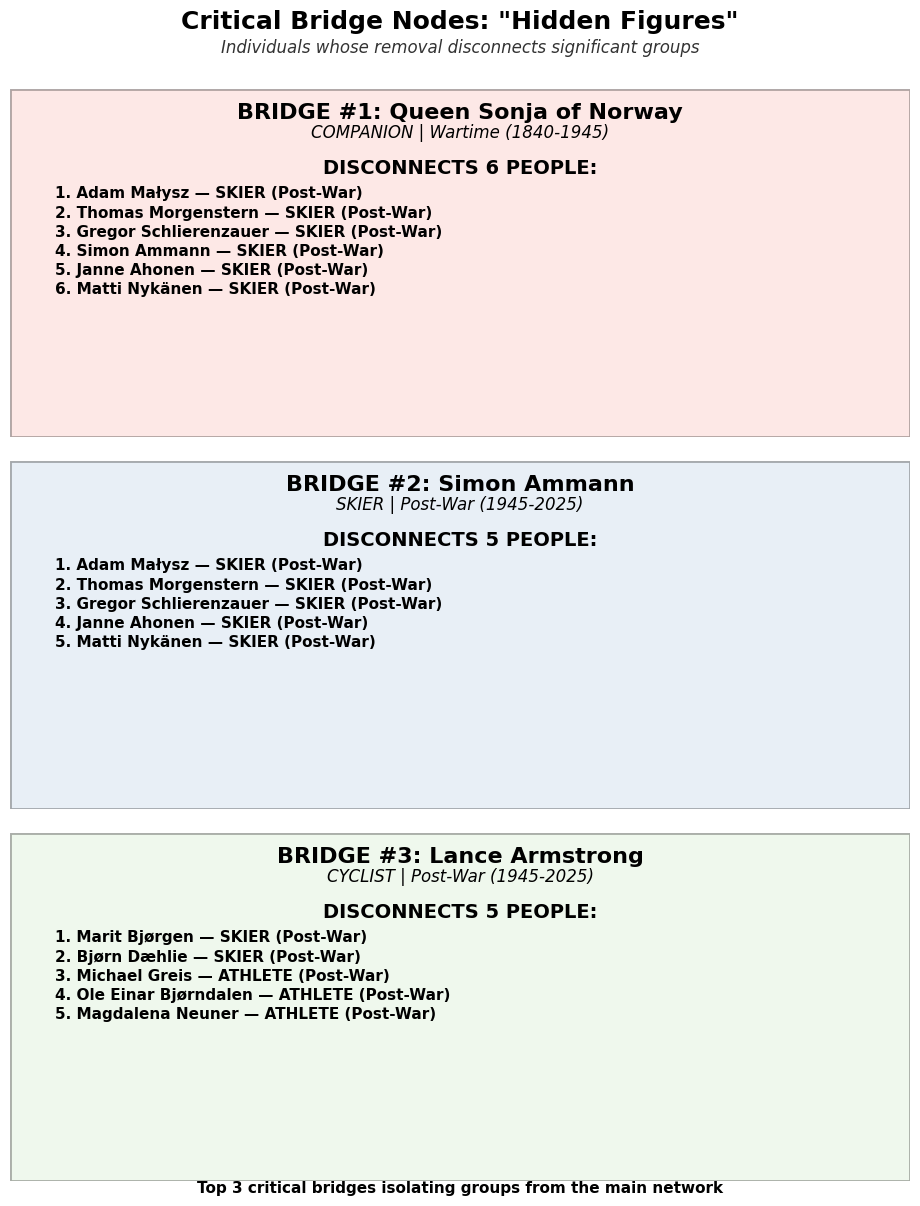

In [38]:
# Prepare data
top_3 = critical_bridges[:3]

# Create figure with reduced size but larger fonts
fig = plt.figure(figsize=(10, 12))
fig.patch.set_facecolor('white')

# Main title - larger font
fig.text(0.5, 0.98, 'Critical Bridge Nodes: "Hidden Figures"', 
         ha='center', fontsize=18, fontweight='bold')
fig.text(0.5, 0.96, 'Individuals whose removal disconnects significant groups', 
         ha='center', fontsize=12, style='italic', alpha=0.8)

# Create 3 panels (one for each bridge)
for idx, bridge in enumerate(top_3):
    # Calculate panel position
    top = 0.93 - (idx * 0.31)
    bottom = top - 0.29
    
    ax = fig.add_axes([0.05, bottom, 0.90, 0.29])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Get disconnected component
    temp_network = largest_subgraph.copy()
    temp_network.remove_node(bridge['node'])
    components = list(nx.connected_components(temp_network))
    component_sizes = sorted(components, key=len, reverse=True)
    smaller_component = component_sizes[1]
    
    # Get detailed info about separated people
    separated_people = []
    for node_id in smaller_component:
        name = network.nodes[node_id].get('Name', 'Unknown')
        occupation = network.nodes[node_id].get('occupation', 'Unknown')
        era = get_era(network.nodes[node_id].get('birthyear'))
        separated_people.append({
            'name': name,
            'occupation': occupation,
            'era': era
        })
    
    # Background
    bg_color = plt.cm.Pastel1(idx % 9)
    rect = plt.Rectangle((0, 0), 1, 1, facecolor=bg_color, alpha=0.3, 
                         edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    
    # Bridge person header - larger font
    y_pos = 0.96
    ax.text(0.5, y_pos, f'BRIDGE #{idx+1}: {bridge["name"]}', 
            ha='center', va='top', fontsize=16, fontweight='bold')
    
    y_pos -= 0.06
    ax.text(0.5, y_pos, f'{bridge["occupation"]} | {bridge["era"]}', 
            ha='center', va='top', fontsize=12, style='italic')
    
    # Disconnected people header - larger font
    y_pos -= 0.10
    ax.text(0.5, y_pos, f'DISCONNECTS {len(smaller_component)} PEOPLE:', 
            ha='center', va='top', fontsize=14, fontweight='bold')
    
    # Simple list of people - larger font, fewer entries
    y_pos -= 0.08
    for i, person in enumerate(separated_people[:10]):  # Reduced to 10 entries
        name_display = person['name'][:30] if len(person['name']) > 30 else person['name']
        occ_display = person['occupation'][:25] if len(person['occupation']) > 25 else person['occupation']
        era_display = person['era'].split(' (')[0]
        
        # Simple text line with larger font
        line_text = f"{i+1}. {name_display} — {occ_display} ({era_display})"
        ax.text(0.05, y_pos, line_text, ha='left', va='top', fontsize=11, fontweight='bold')
        
        y_pos -= 0.055
    
    # "and more" text - larger font
    if len(separated_people) > 10:
        ax.text(0.5, y_pos - 0.02, f'... and {len(separated_people) - 10} more', 
                ha='center', va='top', fontsize=11, style='italic', fontweight='bold')

# Footer - larger font
fig.text(0.5, 0.01, 'Top 3 critical bridges isolating groups from the main network', 
         ha='center', fontsize=11, fontweight='bold')
plt.show()